# BÁO CÁO MÔN PHÂN TÍCH DỮ LIỆU
## Đề tài: Phân tích khám phá về bệnh đái tháo đường (Pima Indians Diabetes)
**Giảng viên hướng dẫn:** ThS. Đỗ Như Tài  
**Nhóm sinh viên thực hiện:** 
Lê Huy Hoàng	3124410104 
Nguyễn Hoài Bảo	3124560009
Phạm Hữu Phú Khánh	3124410152
Nguyễn Văn Đạt	3124410062


---  
## Bước 1: Khai báo và Thiết lập

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

import numpy as np

# Các thư viện từ Scikit-Learn cho Tiền xử lý và Mô hình
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
# Import thêm thư viện Logistic Regression
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



---  
## Bước 2: Định nghĩa vấn đề và Tải dữ liệu
+ **Mô tả**: Dự đoán một bệnh nhân có khả năng mắc bệnh đái tháo đường trong 5 năm tới hay không.
+ **Dữ liệu**: Được nạp từ file `diabetes.csv` nằm cùng thư mục với file notebook này.

In [42]:
# 1. Đọc dữ liệu
df = pd.read_csv('pima-diabetes.csv', header=None)

# 2. Đặt tên cột CHUẨN TRƯỚC khi xử lý
df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
              'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# 3. Xử lý trùng lặp
duplicate_count = df.duplicated().sum()
print(f"Số lượng dòng bị trùng lặp: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)



print("\n--- Dữ liệu sau khi nạp và đặt tên cột ---")
print(df.head())

Số lượng dòng bị trùng lặp: 0

--- Dữ liệu sau khi nạp và đặt tên cột ---
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


## Bước 3: Xử lý tiền dữ liệu

In [43]:
def impute_zero_with_median(df, columns_to_impute):
    df_imputed = df.copy()
    
    print("=== TIẾN TRÌNH THAY THẾ GIÁ TRỊ 0 BẰNG MEDIAN ===")
    
    for col in columns_to_impute:
        if col in df_imputed.columns:
            # Chuyển 0 thành NaN để không làm lệch giá trị Median
            col_data = df_imputed[col].replace(0, np.nan)
            
            # Tính trung vị của các giá trị khác 0
            median_value = col_data.median()
            
            # Đếm số lượng giá trị 0 trước khi thay thế
            num_zeros = (df_imputed[col] == 0).sum()
            
            # Thay thế 0 bằng Median
            df_imputed[col] = df_imputed[col].replace(0, median_value)
            
            print(f"- Cột '{col}': Đã thay thế {num_zeros} giá trị (0) bằng Median = {median_value:.2f}")
    
    print("-" * 45)
    return df_imputed



# 1. Định nghĩa các ngưỡng chuẩn (Ranges)
physiological_ranges = {
    'Pregnancies': (0, 20),
    'Glucose': (20, 300),
    'BloodPressure': (40, 200),
    'BMI': (10, 80),
    'Age': (21, 100)
}


# 2. Bước LOẠI BỎ: Tạo bản sao và lọc bỏ dòng lỗi
df_cleaned = df.copy()

for col, (low, high) in physiological_ranges.items():
    if col in df_cleaned.columns:
        df_cleaned = df_cleaned[(df_cleaned[col] >= low) & (df_cleaned[col] <= high)]

# 3. Reset index để các dòng liên tục trở lại
df_cleaned = df_cleaned.reset_index(drop=True)

# 4. Kiểm tra kết quả
print("=== KẾT QUẢ SAU KHI LOẠI BỎ DÒNG LỖI ===")
print(f"Dữ liệu ban đầu: {len(df)} dòng")
print(f"Dữ liệu sau khi lọc: {len(df_cleaned)} dòng")
print(f"Số dòng đã xóa: {len(df) - len(df_cleaned)}")
print(f"Tỷ lệ giữ lại: {len(df_cleaned)/len(df)*100:.1f}%")


# Danh sách các cột còn lại cần xử lý như bạn yêu cầu
remaining_cols = ['SkinThickness', 'Insulin']

# Giả sử df_cleaned là kết quả từ bước lọc Glucose/BMI trước đó
df_final = impute_zero_with_median(df_cleaned, remaining_cols)

# Kiểm tra lại xem còn giá trị 0 nào không
print("Số lượng giá trị 0 còn sót lại:")
print(df_final[remaining_cols].eq(0).sum())

X = df_final.drop(columns=['Outcome'])
y = df_final['Outcome']

# Chia dữ liệu: 80% để huấn luyện, 20% để kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

# fit_transform cho tập train để máy "học" phân phối dữ liệu
X_train_scaled = scaler.fit_transform(X_train)
# transform cho tập test dựa trên những gì đã học từ tập train
X_test_scaled = scaler.transform(X_test)

=== KẾT QUẢ SAU KHI LOẠI BỎ DÒNG LỖI ===
Dữ liệu ban đầu: 768 dòng
Dữ liệu sau khi lọc: 720 dòng
Số dòng đã xóa: 48
Tỷ lệ giữ lại: 93.8%
=== TIẾN TRÌNH THAY THẾ GIÁ TRỊ 0 BẰNG MEDIAN ===
- Cột 'SkinThickness': Đã thay thế 192 giá trị (0) bằng Median = 29.00
- Cột 'Insulin': Đã thay thế 332 giá trị (0) bằng Median = 126.00
---------------------------------------------
Số lượng giá trị 0 còn sót lại:
SkinThickness    0
Insulin          0
dtype: int64


In [44]:
desc = df.describe().T[['mean', 'std', 'min', 'max']]
desc['median'] = df.median()
result = desc[['mean', 'std', 'min', 'max', 'median']]

print(result)

                                mean         std     min     max    median
Pregnancies                 3.845052    3.369578   0.000   17.00    3.0000
Glucose                   120.894531   31.972618   0.000  199.00  117.0000
BloodPressure              69.105469   19.355807   0.000  122.00   72.0000
SkinThickness              20.536458   15.952218   0.000   99.00   23.0000
Insulin                    79.799479  115.244002   0.000  846.00   30.5000
BMI                        31.992578    7.884160   0.000   67.10   32.0000
DiabetesPedigreeFunction    0.471876    0.331329   0.078    2.42    0.3725
Age                        33.240885   11.760232  21.000   81.00   29.0000
Outcome                     0.348958    0.476951   0.000    1.00    0.0000


---  
## Bước 4: Phân tích khám phá (EDA)

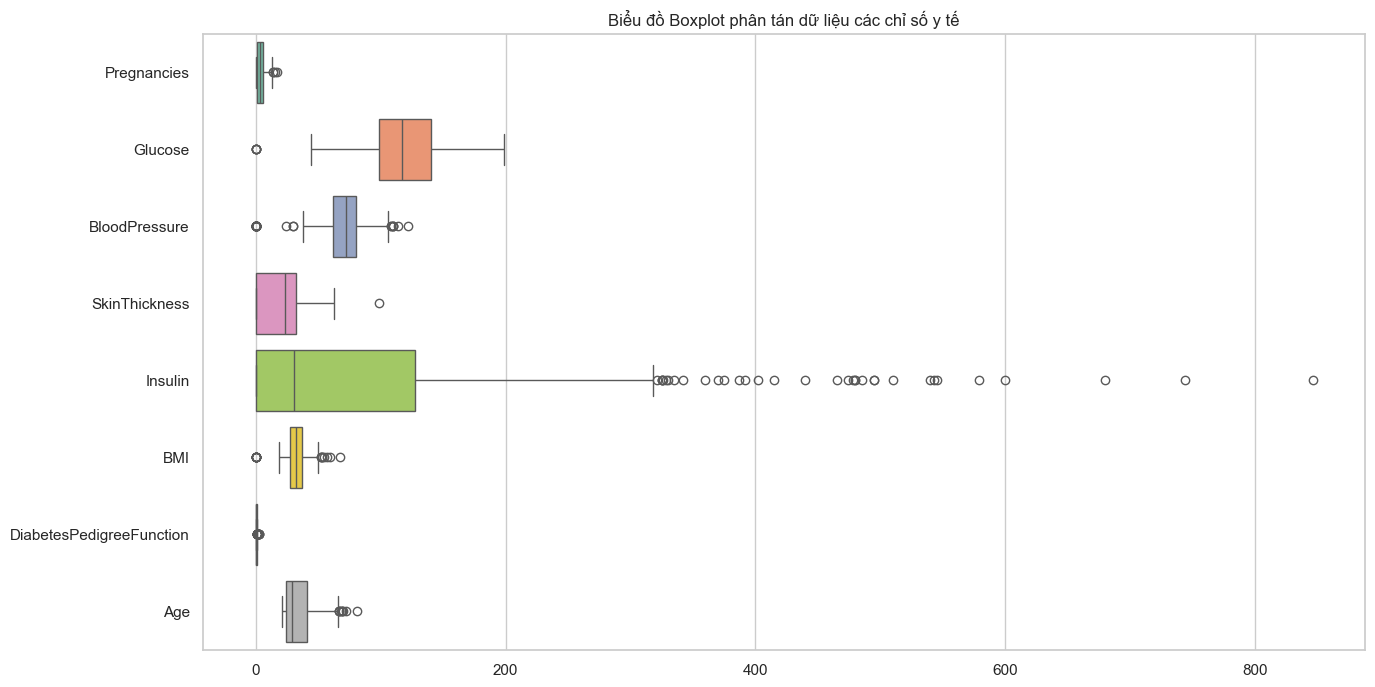

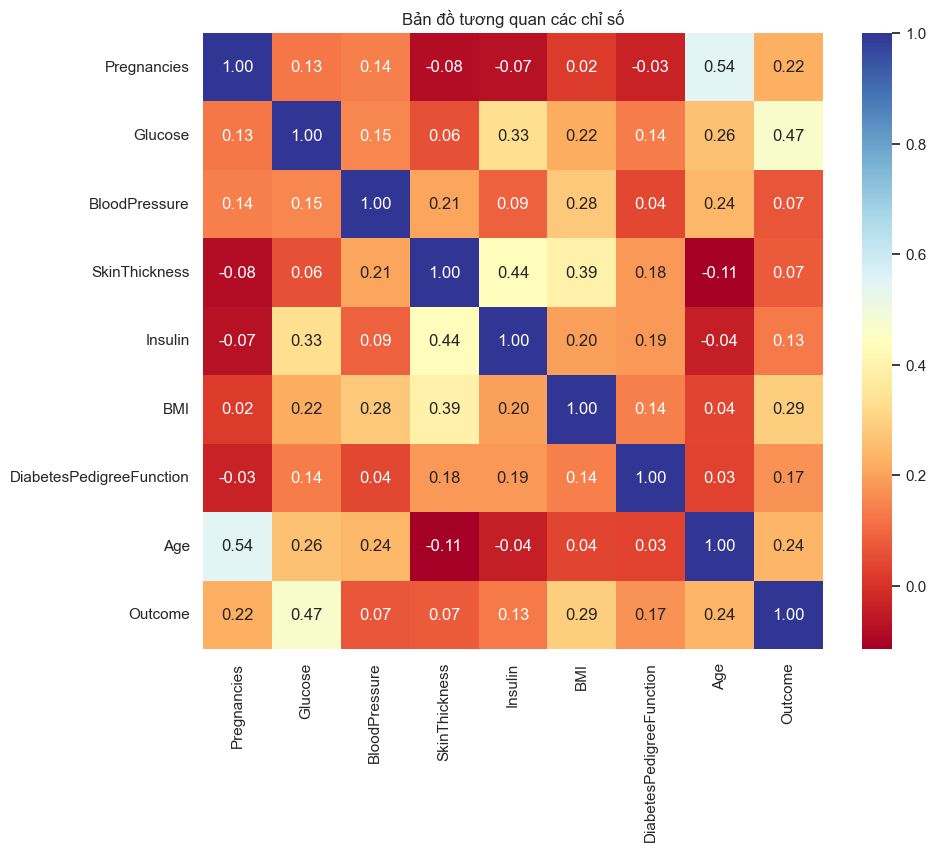

In [45]:
# 1. Vẽ Boxplot kiểm tra ngoại lệ
plt.figure(figsize=(15, 8))
sns.boxplot(data=df.drop('Outcome', axis=1), orient="h", palette="Set2")
plt.title("Biểu đồ Boxplot phân tán dữ liệu các chỉ số y tế")
plt.show()

# 2. Vẽ Heatmap xem tương quan (Chỉ tính toán trên các cột dữ liệu số)
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu', fmt=".2f")
plt.title("Bản đồ tương quan các chỉ số")
plt.show()



Độ chính xác (Accuracy): 76.39%



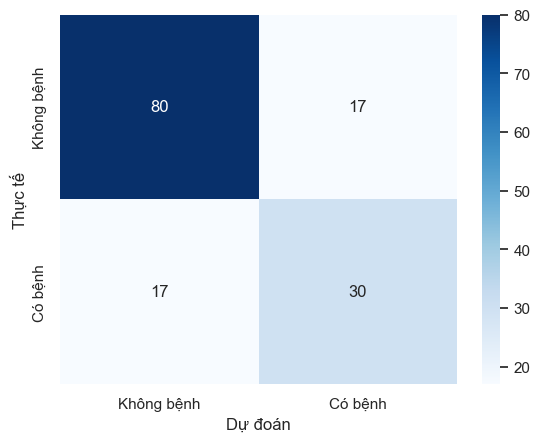


Báo cáo chi tiết:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        97
           1       0.64      0.64      0.64        47

    accuracy                           0.76       144
   macro avg       0.73      0.73      0.73       144
weighted avg       0.76      0.76      0.76       144



In [46]:



# transform cho tập test dựa trên những gì đã học từ tập train
X_test_scaled = scaler.transform(X_test)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f"Độ chính xác (Accuracy): {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Không bệnh', 'Có bệnh'], 
            yticklabels=['Không bệnh', 'Có bệnh'])
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

print("\nBáo cáo chi tiết:")
print(classification_report(y_test, y_pred))

<Axes: xlabel='Độ quan trọng', ylabel='Chỉ số'>

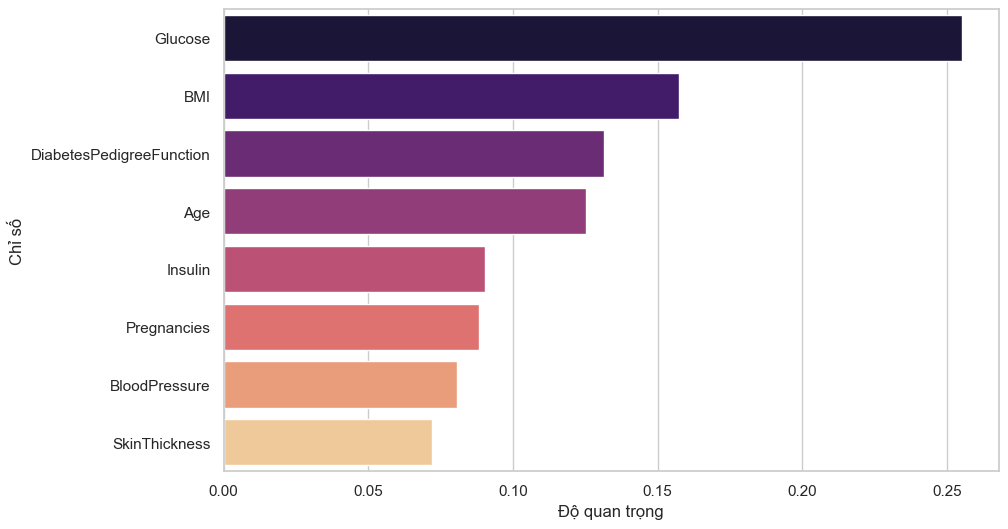

In [47]:
importances = model.feature_importances_

feat_df = pd.DataFrame({
    'Chỉ số': X.columns,
    'Độ quan trọng': importances
}).sort_values(by='Độ quan trọng', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Độ quan trọng', 
    y='Chỉ số', 
    data=feat_df, 
    hue='Chỉ số',      
    palette='magma', 
    legend=False     
)

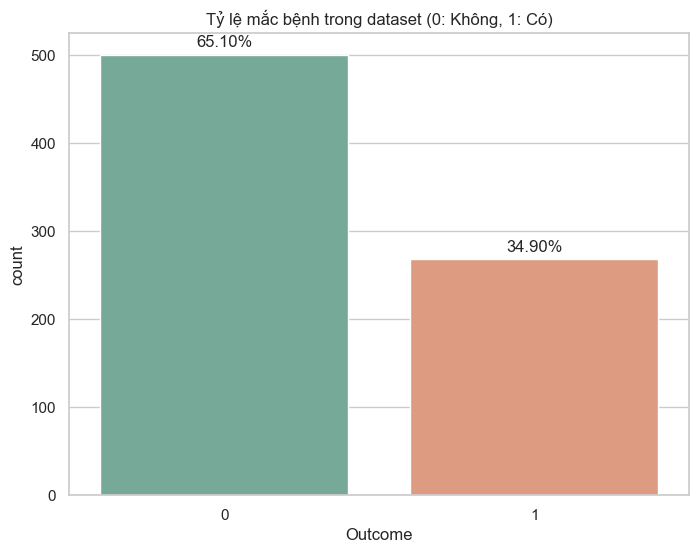

In [48]:
plt.figure(figsize=(8, 6))
# Vẽ biểu đồ đếm số lượng (countplot) với màu sắc tương ứng
ax = sns.countplot(x='Outcome', data=df, palette=['#6eb19b', '#ec9672'], hue='Outcome', legend=False)

total = len(df)
for p in ax.patches:
    # Tính toán tỷ lệ phần trăm cho mỗi cột
    percentage = f'{100 * p.get_height() / total:.2f}%'
    # Gắn nhãn lên đầu cột
    ax.annotate(percentage, 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12)

plt.title('Tỷ lệ mắc bệnh trong dataset (0: Không, 1: Có)')
plt.xlabel('Outcome')
plt.ylabel('count')
plt.show()

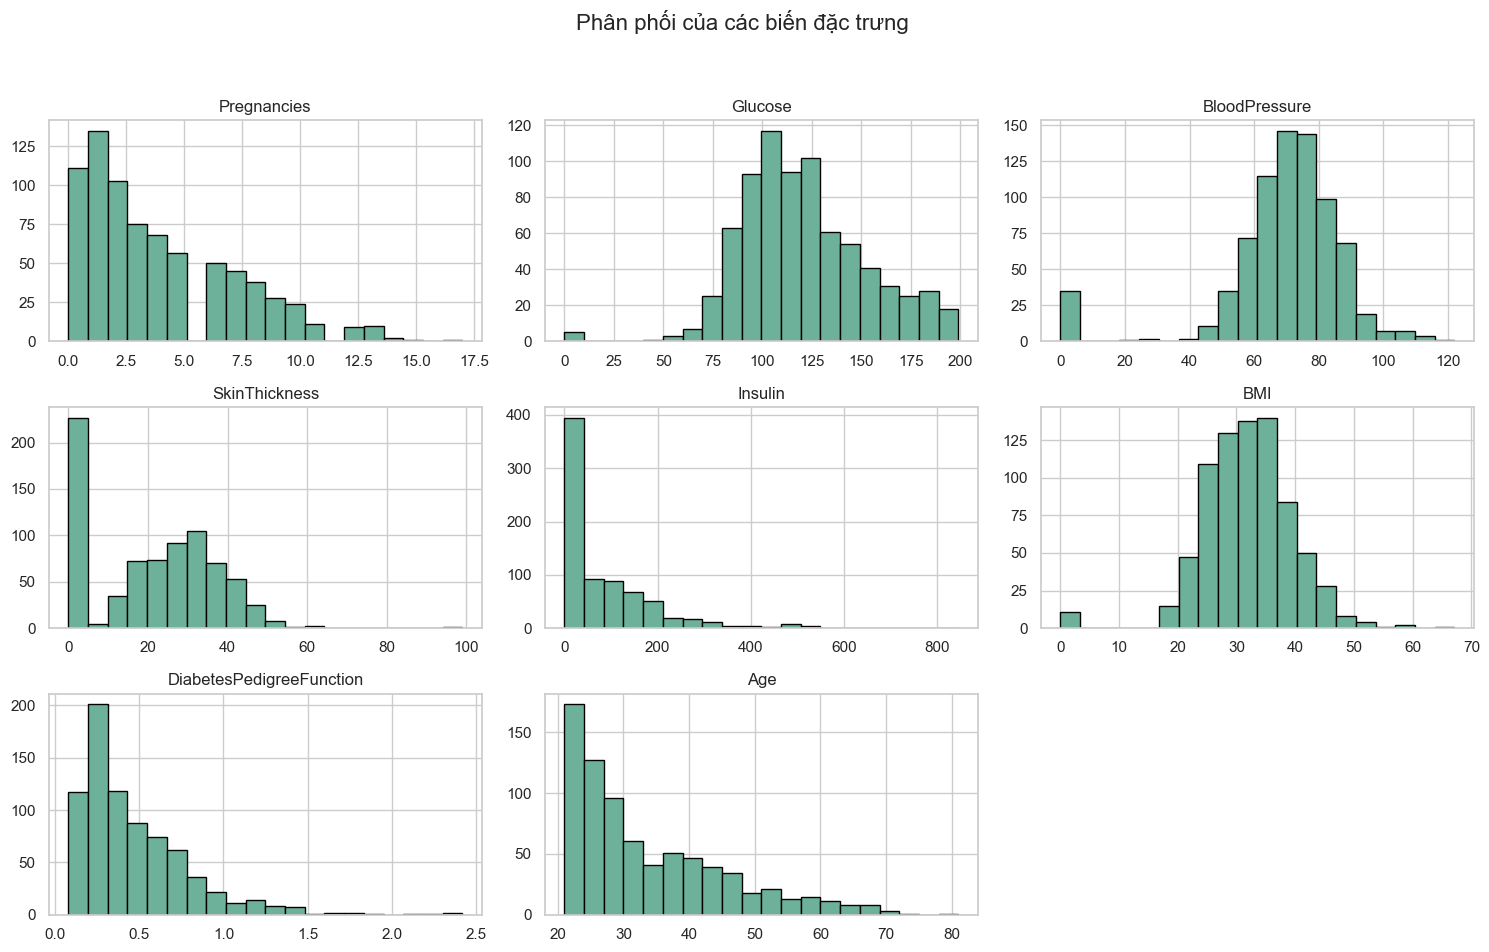

In [49]:
df.iloc[:, :-1].hist(figsize=(15, 10), bins=20, color='#6eb19b', edgecolor='black')
plt.suptitle('Phân phối của các biến đặc trưng', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

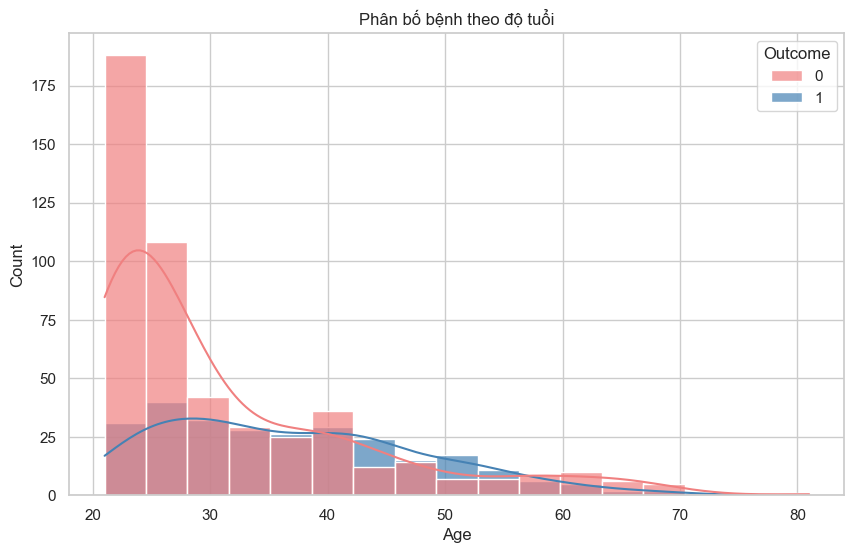

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ histplot
sns.histplot(data=df, x='Age', hue='Outcome', kde=True, 
             palette={0: 'lightcoral', 1: 'steelblue'}, 
             alpha=0.7, element="bars")

# Thiết lập tiêu đề và nhãn
plt.title('Phân bố bệnh theo độ tuổi')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

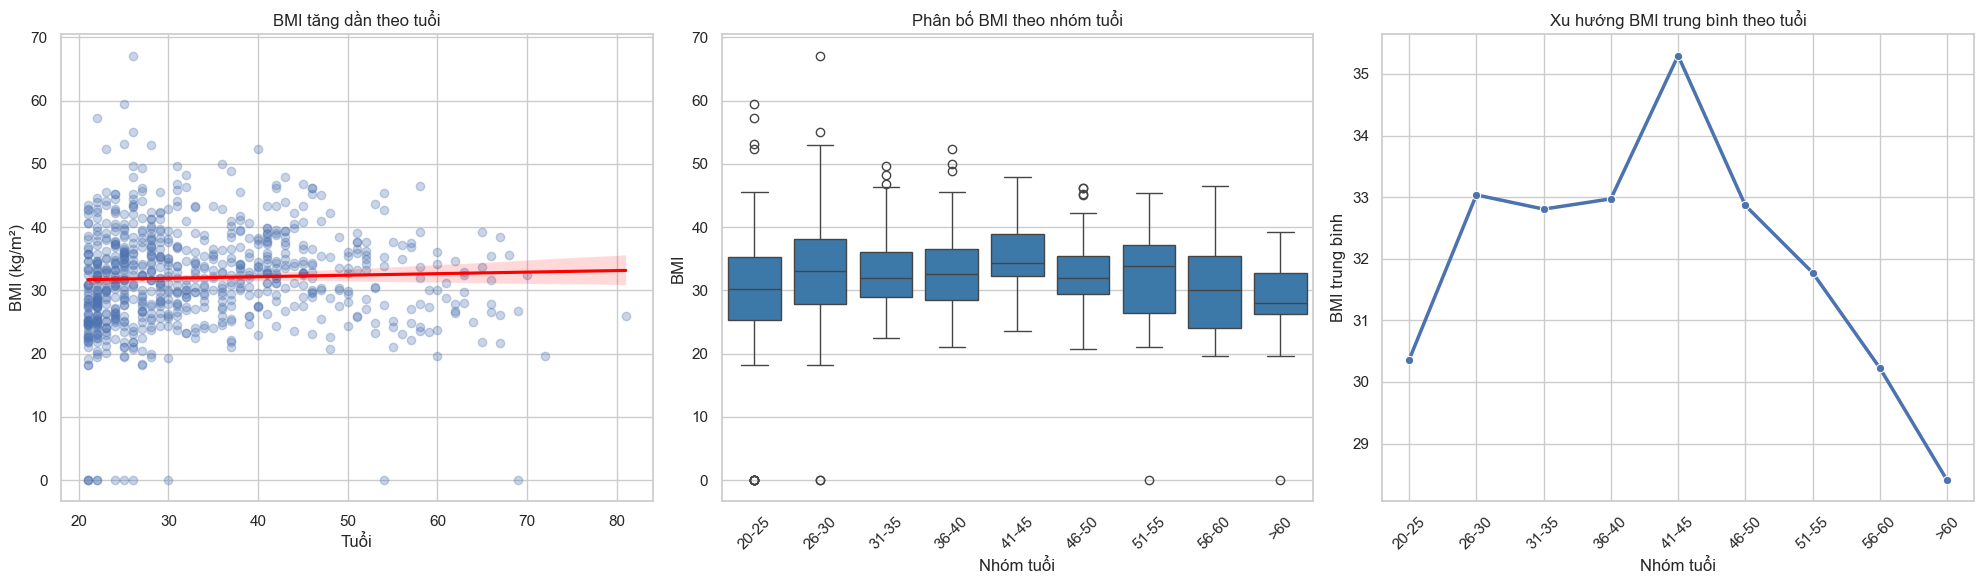

In [51]:

bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 85]
labels = ['20-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-55', '56-60', '>60']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Khởi tạo khung hình có 3 cột
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Biểu đồ 1: Scatter Plot với Regression Line ---
sns.regplot(data=df, x='Age', y='BMI', ax=axes[0], 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title('BMI tăng dần theo tuổi')
axes[0].set_xlabel('Tuổi')
axes[0].set_ylabel('BMI (kg/m²)')

# --- Biểu đồ 2: Boxplot theo nhóm tuổi ---
sns.boxplot(data=df, x='AgeGroup', y='BMI', ax=axes[1], color='#2b7bba')
axes[1].set_title('Phân bố BMI theo nhóm tuổi')
axes[1].set_xlabel('Nhóm tuổi')
axes[1].tick_params(axis='x', rotation=45)

# --- Biểu đồ 3: Line Plot (BMI trung bình) ---
bmi_means = df.groupby('AgeGroup')['BMI'].mean().reset_index()
sns.lineplot(data=bmi_means, x='AgeGroup', y='BMI', marker='o', ax=axes[2], linewidth=2.5)
axes[2].set_title('Xu hướng BMI trung bình theo tuổi')
axes[2].set_xlabel('Nhóm tuổi')
axes[2].set_ylabel('BMI trung bình')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

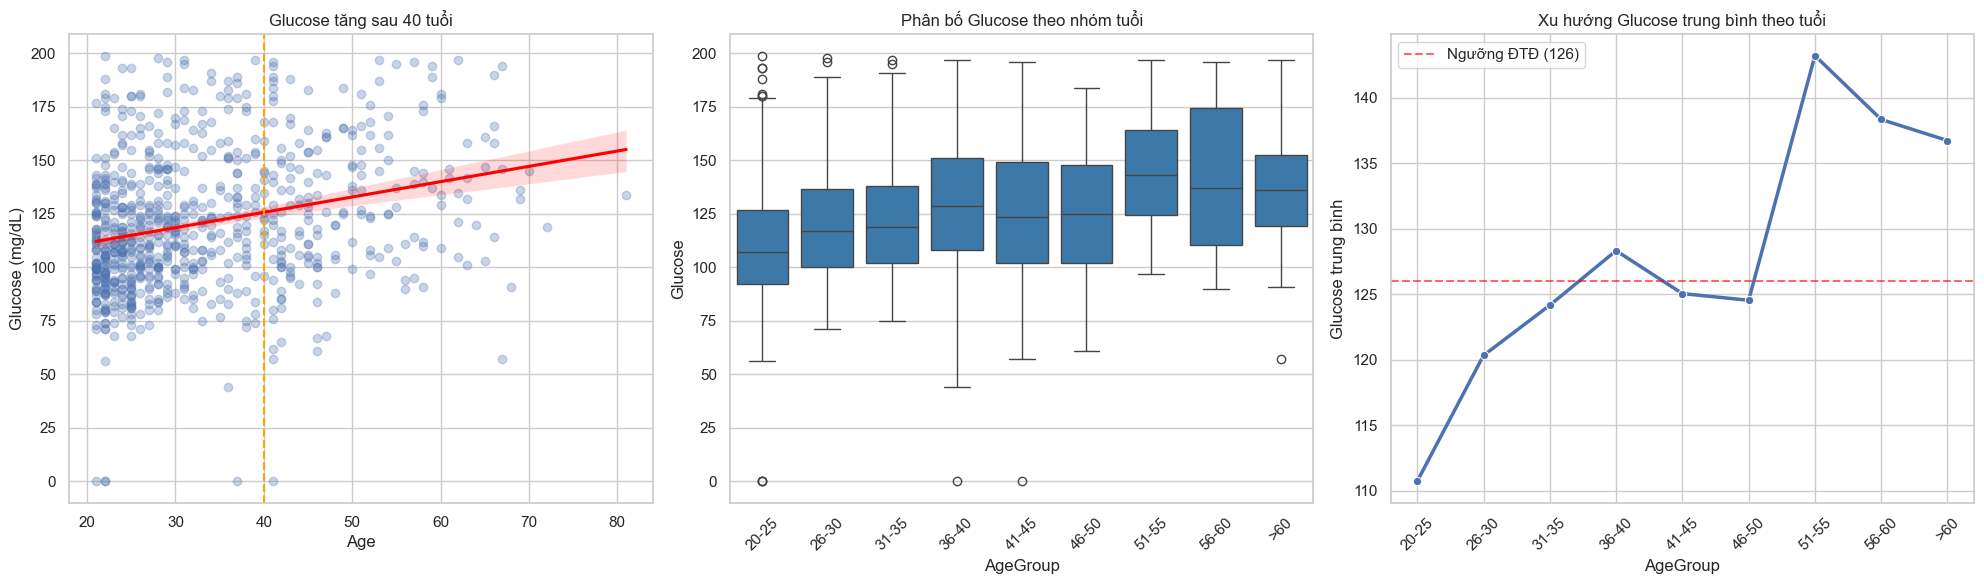

In [52]:
# 1. Phân nhóm tuổi 
bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 85]
labels = ['20-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-55', '56-60', '>60']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Biểu đồ 1: Scatter Plot + Regression + Vline tại 40 tuổi ---
sns.regplot(data=df, x='Age', y='Glucose', ax=axes[0], 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].axvline(x=40, color='orange', linestyle='--') # Đường cam đứt đoạn tại tuổi 40
axes[0].set_title('Glucose tăng sau 40 tuổi')
axes[0].set_ylabel('Glucose (mg/dL)')

# --- Biểu đồ 2: Boxplot theo nhóm tuổi ---
sns.boxplot(data=df, x='AgeGroup', y='Glucose', ax=axes[1], color='#2b7bba')
axes[1].set_title('Phân bố Glucose theo nhóm tuổi')
axes[1].tick_params(axis='x', rotation=45)

# --- Biểu đồ 3: Line Plot + Ngưỡng ĐTĐ (126) ---
glucose_means = df.groupby('AgeGroup')['Glucose'].mean().reset_index()
sns.lineplot(data=glucose_means, x='AgeGroup', y='Glucose', marker='o', ax=axes[2], linewidth=2.5)
axes[2].axhline(y=126, color='red', linestyle='--', alpha=0.6, label='Ngưỡng ĐTĐ (126)') # Đường ngưỡng
axes[2].set_title('Xu hướng Glucose trung bình theo tuổi')
axes[2].set_ylabel('Glucose trung bình')
axes[2].legend() 
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

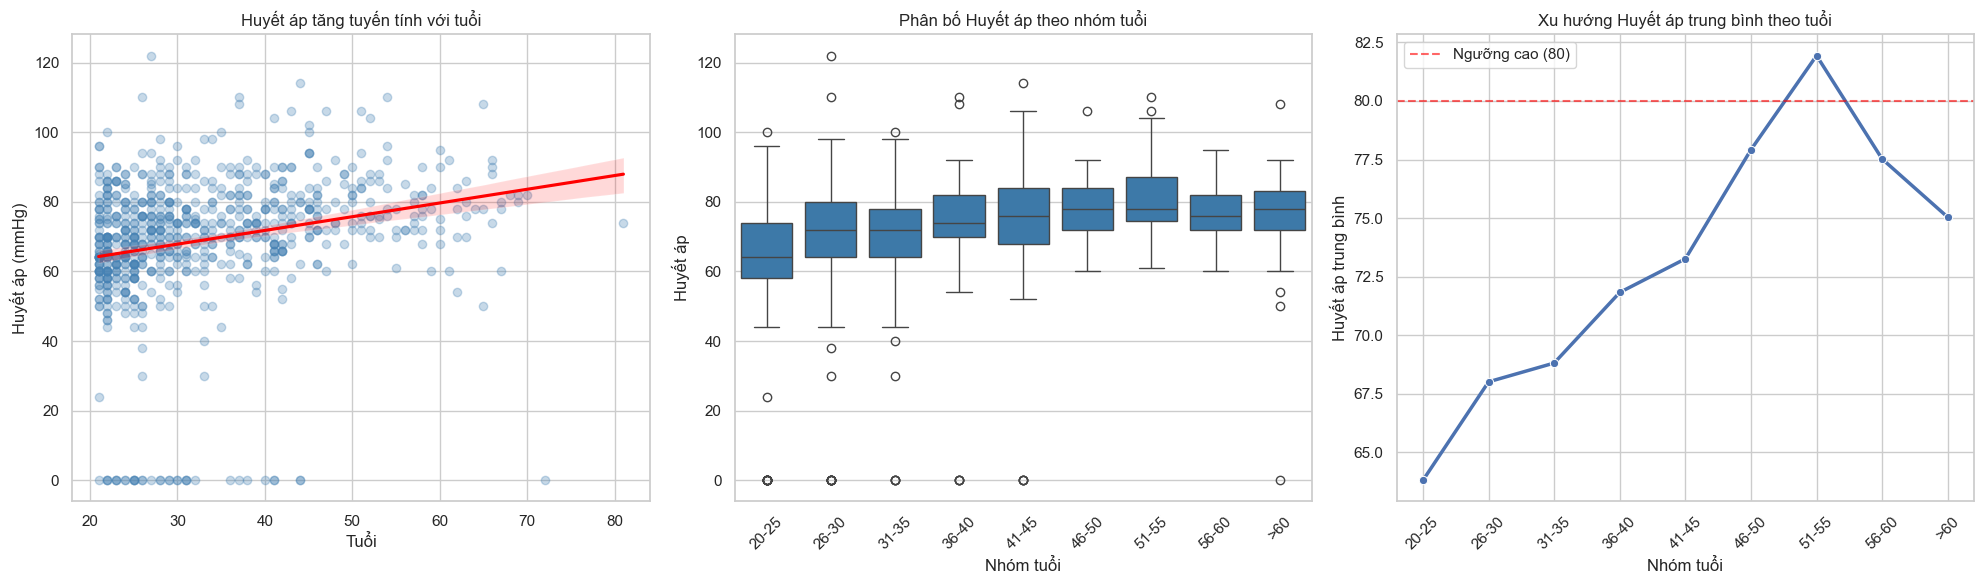

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Phân nhóm tuổi (để vẽ Boxplot và Lineplot)
bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 85]
labels = ['20-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-55', '56-60', '>60']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Khởi tạo khung hình 1 hàng 3 cột
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- BIỂU ĐỒ 1: Scatter Plot + Regression Line ---
sns.regplot(data=df, x='Age', y='BloodPressure', ax=axes[0], 
            scatter_kws={'alpha':0.3, 'color':'steelblue'}, 
            line_kws={'color':'red'})
axes[0].set_title('Huyết áp tăng tuyến tính với tuổi')
axes[0].set_xlabel('Tuổi')
axes[0].set_ylabel('Huyết áp (mmHg)')

# --- BIỂU ĐỒ 2: Boxplot ---
sns.boxplot(data=df, x='AgeGroup', y='BloodPressure', ax=axes[1], color='#2b7bba')
axes[1].set_title('Phân bố Huyết áp theo nhóm tuổi')
axes[1].set_xlabel('Nhóm tuổi')
axes[1].set_ylabel('Huyết áp')
axes[1].tick_params(axis='x', rotation=45) 

# --- BIỂU ĐỒ 3: Line Plot + Ngưỡng cao (80) ---
# Tính trung bình huyết áp theo nhóm tuổi
bp_means = df.groupby('AgeGroup', observed=True)['BloodPressure'].mean().reset_index()

sns.lineplot(data=bp_means, x='AgeGroup', y='BloodPressure', marker='o', ax=axes[2], linewidth=2.5)
axes[2].axhline(y=80, color='red', linestyle='--', alpha=0.6, label='Ngưỡng cao (80)')
axes[2].set_title('Xu hướng Huyết áp trung bình theo tuổi')
axes[2].set_xlabel('Nhóm tuổi')
axes[2].set_ylabel('Huyết áp trung bình')
axes[2].legend() 
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

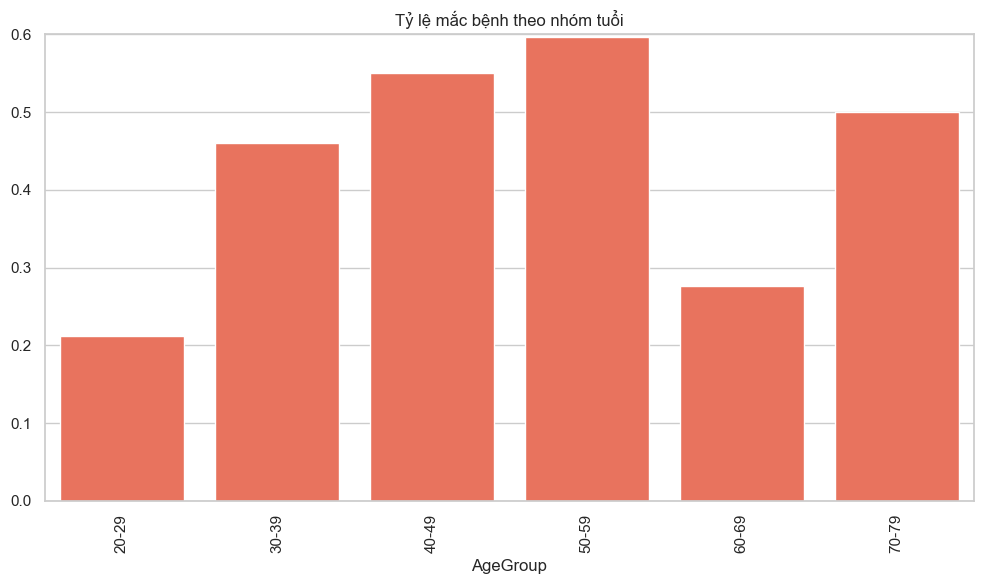

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


bins = [20, 30, 40, 50, 60, 70, 80]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# 2. Tính tỷ lệ mắc bệnh (Outcome = 1) trung bình cho mỗi nhóm
age_outcome_ratio = df.groupby('AgeGroup', observed=True)['Outcome'].mean().reset_index()

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(data=age_outcome_ratio, x='AgeGroup', y='Outcome', color='#ff6347') # Màu cam đỏ (Tomato)

# 4. Tùy chỉnh định dạng giống ảnh
plt.title('Tỷ lệ mắc bệnh theo nhóm tuổi')
plt.xlabel('AgeGroup')
plt.ylabel('') 
plt.xticks(rotation=90) 
plt.ylim(0, 0.6) 

plt.tight_layout()
plt.show()

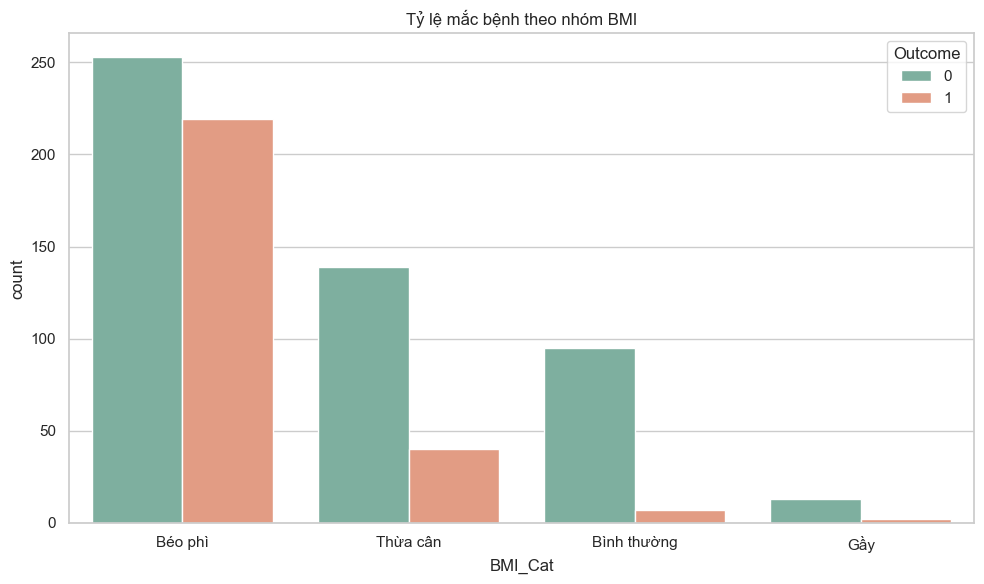

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Hàm phân loại BMI theo chuẩn WHO
def classify_bmi(bmi):
    if bmi < 18.5:
        return 'Gầy'
    elif 18.5 <= bmi < 25:
        return 'Bình thường'
    elif 25 <= bmi < 30:
        return 'Thừa cân'
    else:
        return 'Béo phì'

# Áp dụng phân loại vào dataframe
df['BMI_Cat'] = df['BMI'].apply(classify_bmi)

# Sắp xếp thứ tự hiển thị để giống ảnh (Béo phì -> Thừa cân -> Bình thường -> Gầy)
order = ['Béo phì', 'Thừa cân', 'Bình thường', 'Gầy']

# 2. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='BMI_Cat', hue='Outcome', order=order, 
              palette={0: '#76b7a2', 1: '#f19475'}) # Màu xanh ngọc và cam nhạt

# 3. Tùy chỉnh định dạng
plt.title('Tỷ lệ mắc bệnh theo nhóm BMI')
plt.xlabel('BMI_Cat')
plt.ylabel('count')
plt.legend(title='Outcome', loc='upper right')

plt.tight_layout()
plt.show()

In [56]:
import pandas as pd

# 1. Định nghĩa hàm phân loại BMI (Chuẩn WHO)
def classify_bmi(bmi):
    if bmi < 18.5: return 'Gầy'
    elif 18.5 <= bmi < 25: return 'Bình thường'
    elif 25 <= bmi < 30: return 'Thừa cân'
    else: return 'Béo phì'

# 2. Áp dụng phân loại
df['BMI_Cat'] = df['BMI'].apply(classify_bmi)

# 3. Tính toán các chỉ số thống kê
summary_table = df.groupby('BMI_Cat').agg(
    Tong_so=('Outcome', 'count'),
    So_ca_mac=('Outcome', 'sum'),
    BMI_trung_binh=('BMI', 'mean')
).reset_index()

# 4. Tính tỷ lệ mắc bệnh (%)
summary_table['Ty_le_mac_percentage'] = (summary_table['So_ca_mac'] / summary_table['Tong_so'] * 100).round(1).astype(str) + '%'

# 5. Sắp xếp lại thứ tự nhóm và đổi tên cột để giống ảnh
order = ['Gầy', 'Bình thường', 'Thừa cân', 'Béo phì']
summary_table['BMI_Cat'] = pd.Categorical(summary_table['BMI_Cat'], categories=order, ordered=True)
summary_table = summary_table.sort_values('BMI_Cat')

summary_table.columns = ['Nhóm BMI', 'Tổng số', 'Số ca mắc', 'BMI trung bình', 'Tỷ lệ mắc (%)']

# Hiển thị bảng
print(summary_table.to_string(index=False))

   Nhóm BMI  Tổng số  Số ca mắc  BMI trung bình Tỷ lệ mắc (%)
        Gầy       15          2        4.866667         13.3%
Bình thường      102          7       22.768627          6.9%
   Thừa cân      179         40       27.500000         22.3%
    Béo phì      472        219       36.551695         46.4%


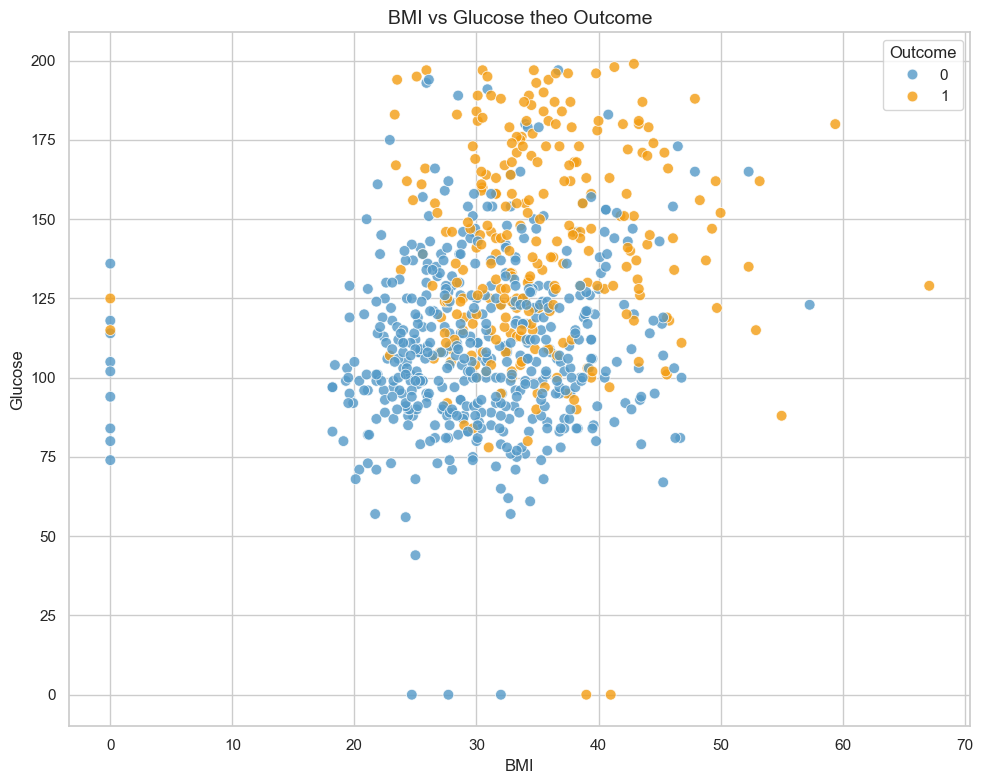

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# Thiết lập kích thước khung hình
plt.figure(figsize=(10, 8))

# Vẽ biểu đồ Scatter (Phân tán)
sns.scatterplot(data=df, x='BMI', y='Glucose', hue='Outcome', 
                palette={0: '#5499c7', 1: '#f39c12'}, 
                alpha=0.8, s=60, edgecolor='w')

# Tùy chỉnh tiêu đề và nhãn trục
plt.title('BMI vs Glucose theo Outcome', fontsize=14)
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Glucose', fontsize=12)

plt.legend(title='Outcome', loc='upper right')

plt.tight_layout()
plt.show()

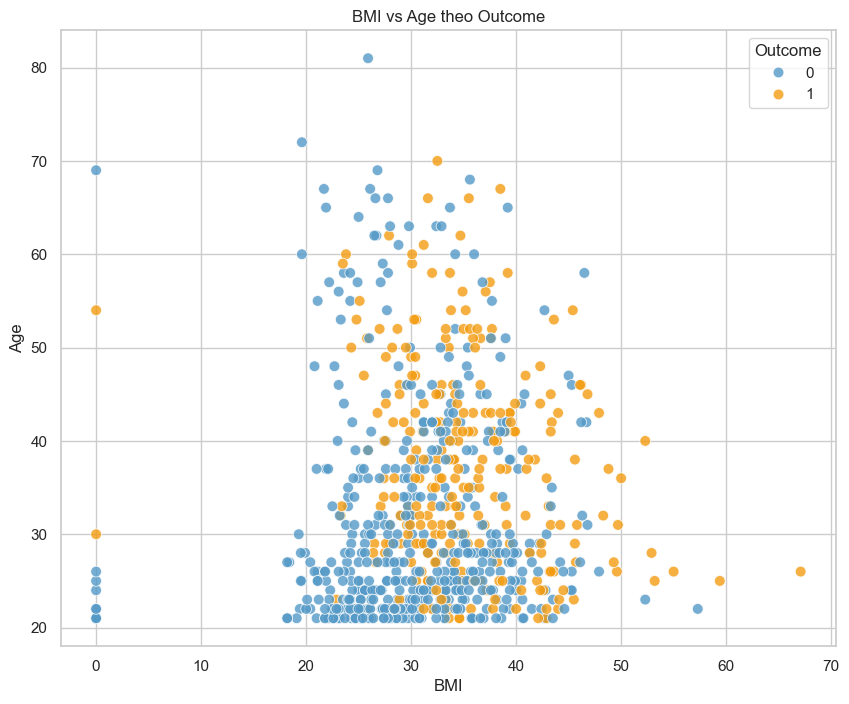

In [58]:


# Thiết lập kích thước khung hình
plt.figure(figsize=(10, 8))

# Vẽ biểu đồ Scatter (Phân tán) BMI vs Age
sns.scatterplot(data=df, x='BMI', y='Age', hue='Outcome', 
                palette={0: '#5499c7', 1: '#f39c12'}, 
                alpha=0.8, s=60, edgecolor='w')

# Tùy chỉnh tiêu đề và nhãn trục
plt.title('BMI vs Age theo Outcome')
plt.xlabel('BMI')
plt.ylabel('Age')

# Hiển thị chú thích (Legend) ở góc trên bên phải
plt.legend(title='Outcome', loc='upper right')

# Hiển thị biểu đồ
plt.show()

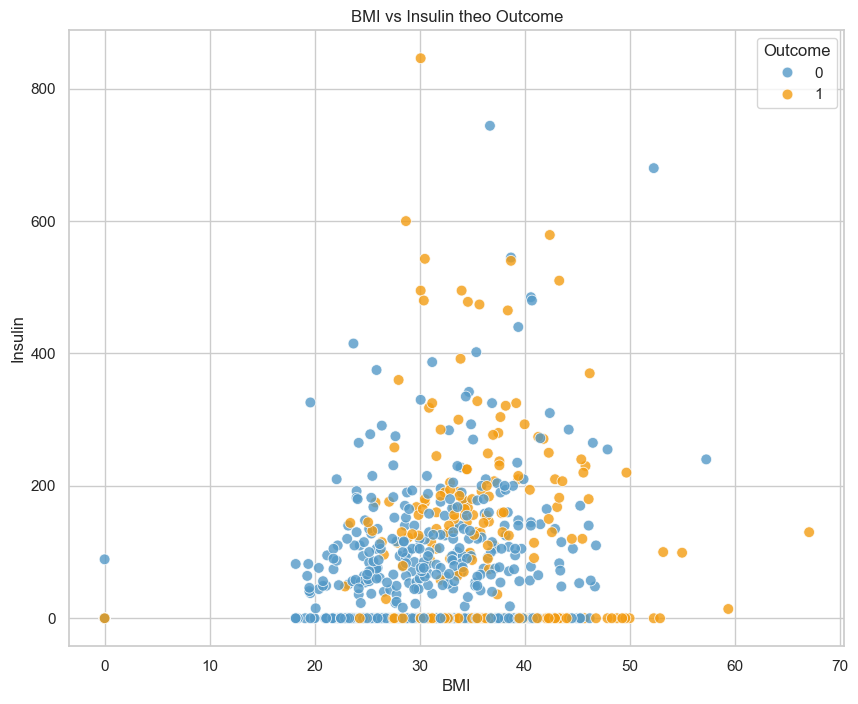

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# Thiết lập kích thước khung hình
plt.figure(figsize=(10, 8))

sns.scatterplot(data=df, x='BMI', y='Insulin', hue='Outcome', 
                palette={0: '#5499c7', 1: '#f39c12'}, # Xanh dương cho 0, Cam cho 1
                alpha=0.8, s=60, edgecolor='w')

# Tùy chỉnh tiêu đề và nhãn trục
plt.title('BMI vs Insulin theo Outcome')
plt.xlabel('BMI')
plt.ylabel('Insulin')

# Đặt chú thích (Legend) ở góc trên bên phải
plt.legend(title='Outcome', loc='upper right')

# Hiển thị biểu đồ
plt.show()

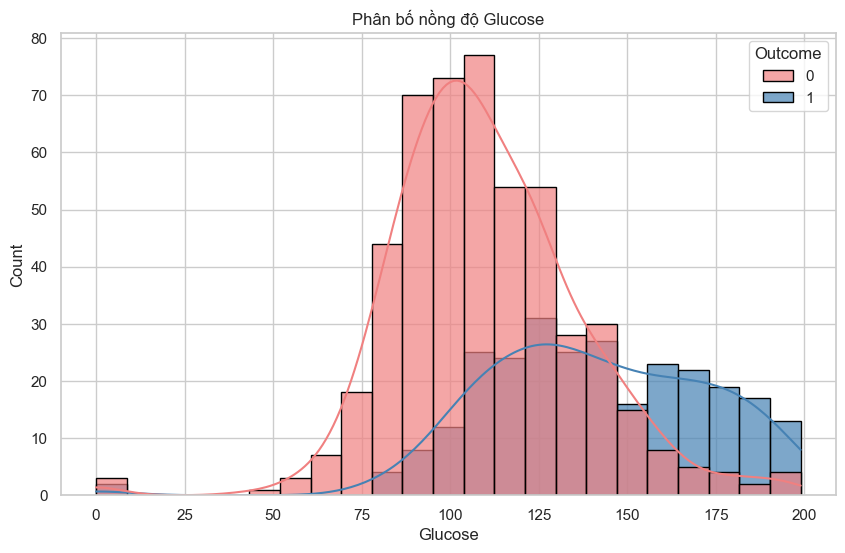

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ phân bố (Histogram) kết hợp đường mật độ (KDE)
sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True, 
             palette={0: 'lightcoral', 1: 'steelblue'},
             alpha=0.7, edgecolor='black')

# Thiết lập tiêu đề và nhãn trục
plt.title('Phân bố nồng độ Glucose')
plt.xlabel('Glucose')
plt.ylabel('Count')

# Hiển thị biểu đồ
plt.show()

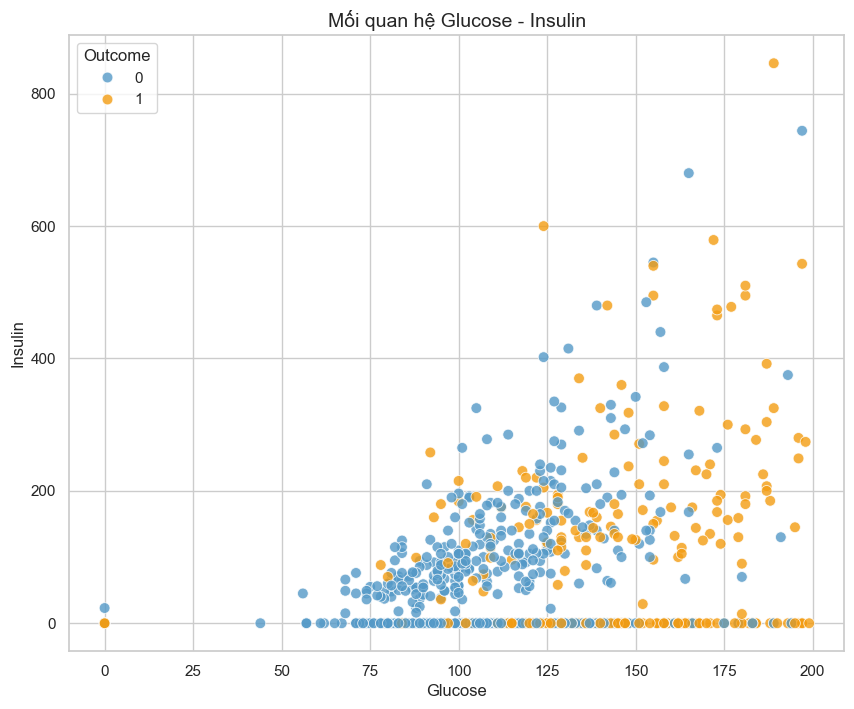

In [61]:
# Thiết lập kích thước khung hình
plt.figure(figsize=(10, 8))

# Vẽ biểu đồ Scatter (Phân tán) giữa Glucose và Insulin
sns.scatterplot(data=df, x='Glucose', y='Insulin', hue='Outcome', 
                palette={0: '#5499c7', 1: '#f39c12'}, # Màu xanh (0) và cam (1)
                alpha=0.8, s=60, edgecolor='w')

# Tùy chỉnh tiêu đề và nhãn trục
plt.title('Mối quan hệ Glucose - Insulin', fontsize=14)
plt.xlabel('Glucose', fontsize=12)
plt.ylabel('Insulin', fontsize=12)

# Đặt chú thích (Legend) ở góc trên bên trái (loc='upper left') để giống hệt ảnh
plt.legend(title='Outcome', loc='upper left')

# Hiển thị biểu đồ
plt.show()

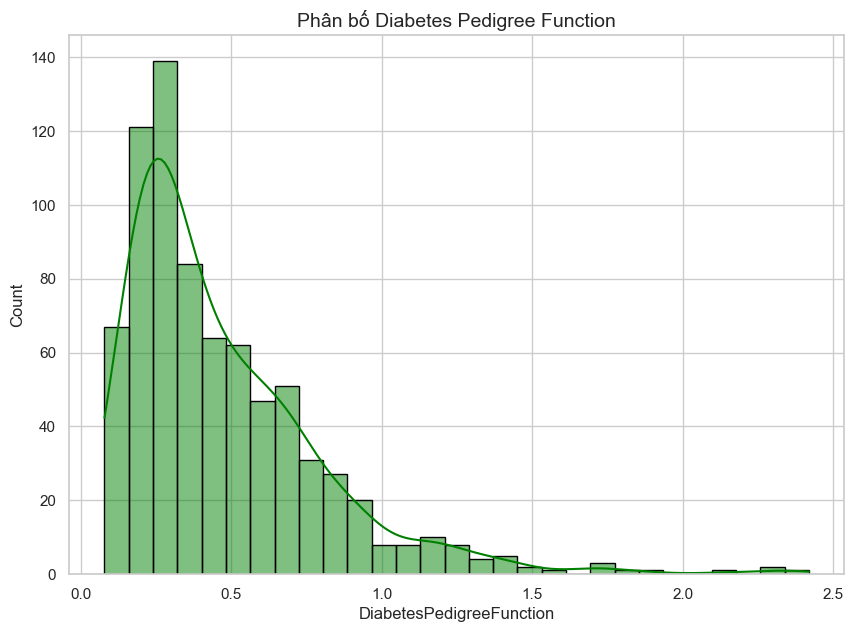

In [62]:
# Thiết lập kích thước biểu đồ
plt.figure(figsize=(10, 7))

# Vẽ biểu đồ phân bố (Histogram) kết hợp đường KDE
sns.histplot(data=df, x='DiabetesPedigreeFunction', kde=True, 
             color='green', alpha=0.5, edgecolor='black')

# Thiết lập tiêu đề và nhãn trục
plt.title('Phân bố Diabetes Pedigree Function', fontsize=14)
plt.xlabel('DiabetesPedigreeFunction', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Hiển thị biểu đồ
plt.show()

C:\Users\nguyenhoaibao\AppData\Local\Temp\ipykernel_23124\2242580076.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y='DiabetesPedigreeFunction',


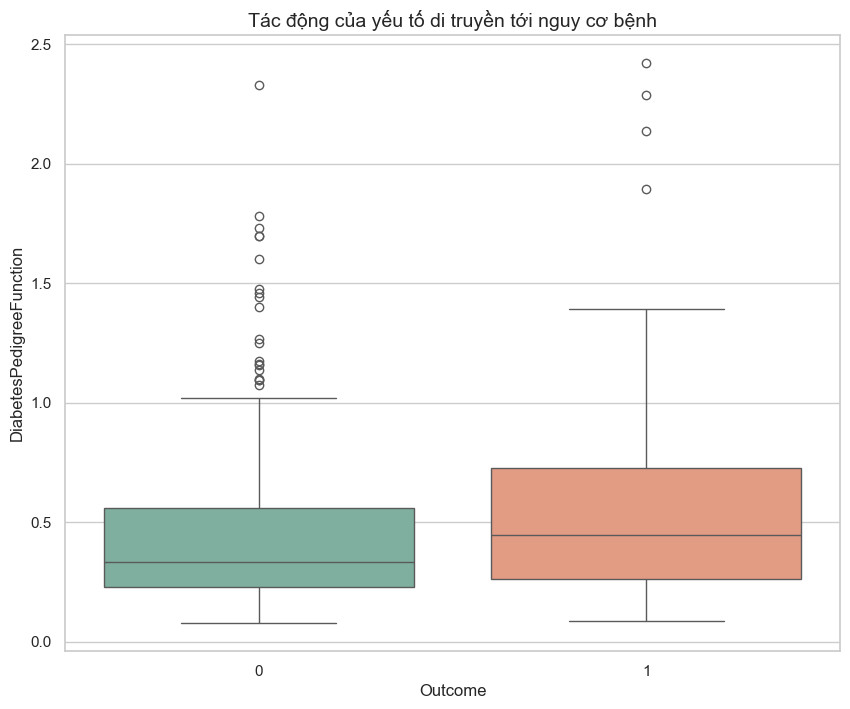

In [63]:
# Thiết lập kích thước khung hình
plt.figure(figsize=(10, 8))

# Vẽ biểu đồ Boxplot - Sửa palette thành dạng chuỗi để khớp với dữ liệu
sns.boxplot(data=df, x='Outcome', y='DiabetesPedigreeFunction', 
            palette={'0': '#76b7a2', '1': '#f19475'}) # Thêm dấu nháy vào '0' và '1'

# Tùy chỉnh tiêu đề và nhãn trục
plt.title('Tác động của yếu tố di truyền tới nguy cơ bệnh', fontsize=14)
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('DiabetesPedigreeFunction', fontsize=12)

# Hiển thị biểu đồ
plt.show()

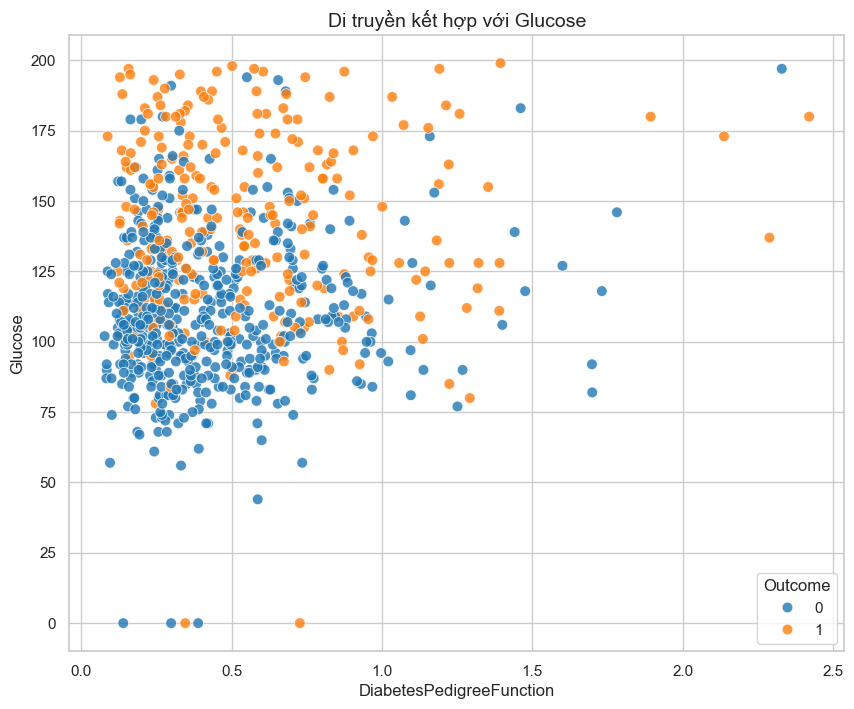

In [64]:
# Thiết lập kích thước khung hình
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df, 
    x='DiabetesPedigreeFunction', 
    y='Glucose', 
    hue='Outcome', 
    palette={0: 'tab:blue', 1: 'tab:orange'}, 
    alpha=0.8, 
    s=60, 
    edgecolor='w'
)

# Tùy chỉnh tiêu đề và nhãn trục
plt.title('Di truyền kết hợp với Glucose', fontsize=14)
plt.xlabel('DiabetesPedigreeFunction', fontsize=12)
plt.ylabel('Glucose', fontsize=12)

# Đặt chú thích (Legend) ở góc dưới bên phải
plt.legend(title='Outcome', loc='lower right')

# Hiển thị biểu đồ
plt.show()

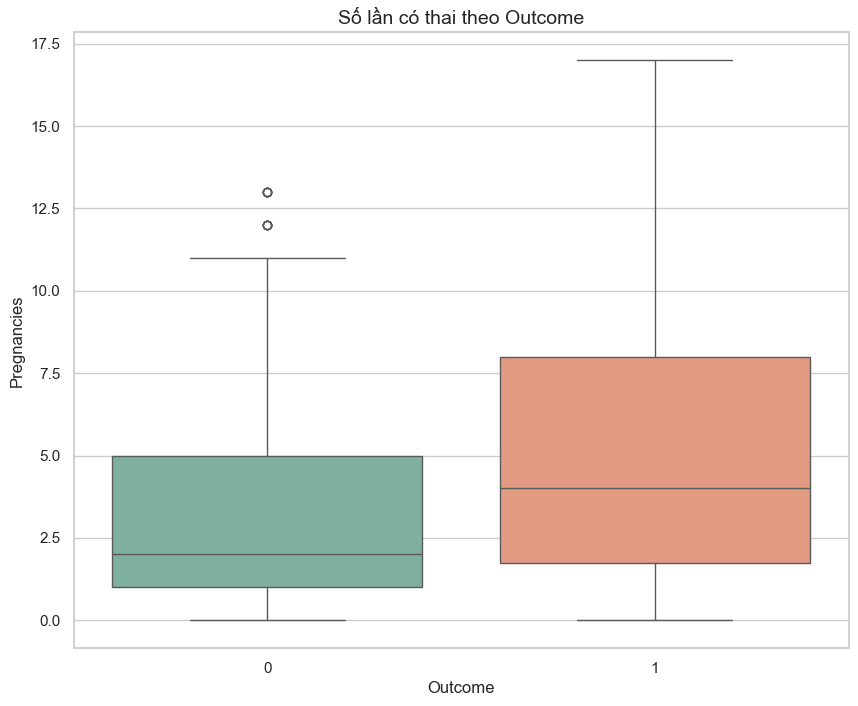

In [65]:
# Thiết lập kích thước khung hình
plt.figure(figsize=(10, 8))

# Vẽ biểu đồ Boxplot cho biến Pregnancies
sns.boxplot(
    data=df, 
    x='Outcome', 
    y='Pregnancies', 
    hue='Outcome', 
    palette={0: '#76b7a2', 1: '#f19475'},
    legend=False
)

# Tùy chỉnh tiêu đề và nhãn trục
plt.title('Số lần có thai theo Outcome', fontsize=14)
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Pregnancies', fontsize=12)

# Hiển thị biểu đồ
plt.show()

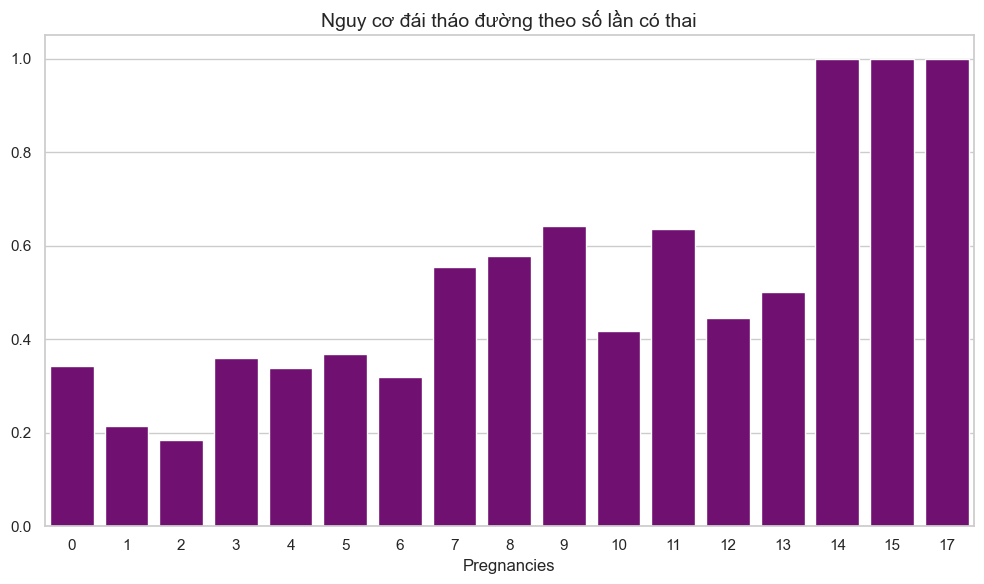

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tính tỷ lệ mắc bệnh (mean của Outcome) theo từng số lần có thai
pregnancy_risk = df.groupby('Pregnancies')['Outcome'].mean().reset_index()

# 2. Thiết lập kích thước khung hình
plt.figure(figsize=(10, 6))

# 3. Vẽ biểu đồ cột (Bar Chart)
sns.barplot(data=pregnancy_risk, x='Pregnancies', y='Outcome', color='purple')

# 4. Tùy chỉnh tiêu đề và nhãn trục
plt.title('Nguy cơ đái tháo đường theo số lần có thai', fontsize=14)
plt.xlabel('Pregnancies', fontsize=12)
plt.ylabel('') 

# 5. Xoay nhãn trục X để dễ nhìn (nếu cần)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

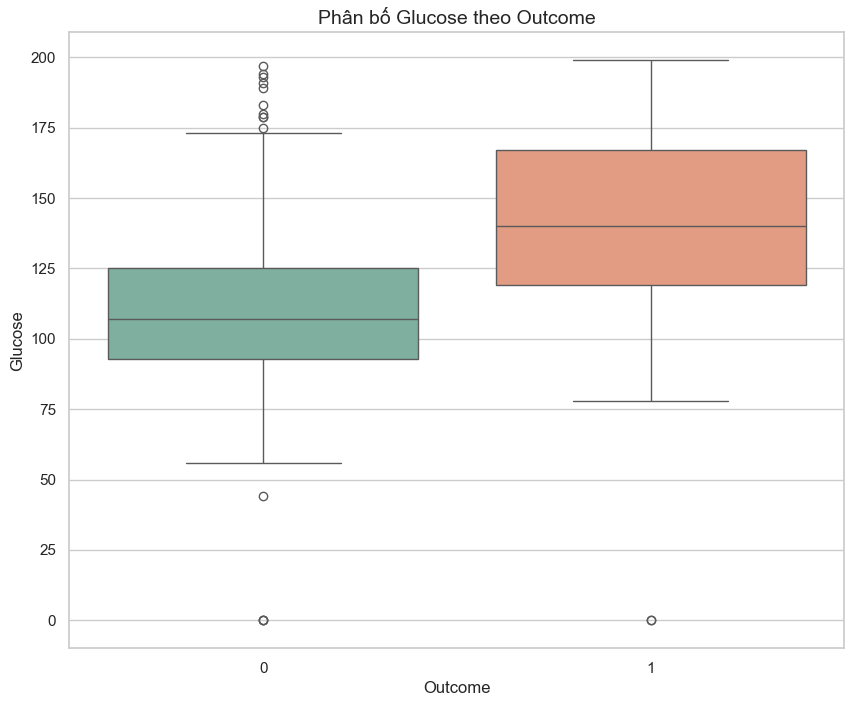

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

# Thiết lập phong cách lưới nền trắng (whitegrid) để giống ảnh mẫu
sns.set_style("whitegrid")

# Thiết lập kích thước khung hình
plt.figure(figsize=(10, 8))

# Vẽ biểu đồ Boxplot cho Glucose
sns.boxplot(
    data=df, 
    x='Outcome', 
    y='Glucose', 
    hue='Outcome', 
    palette={0: '#76b7a2', 1: '#f19475'},
    legend=False
)

# Tùy chỉnh tiêu đề và nhãn trục
plt.title('Phân bố Glucose theo Outcome', fontsize=14)
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Glucose', fontsize=12)

# Hiển thị biểu đồ
plt.show()

C:\Users\nguyenhoaibao\AppData\Local\Temp\ipykernel_23124\546105968.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mutual Information', y='Đặc trưng', data=mi_df, palette='viridis')


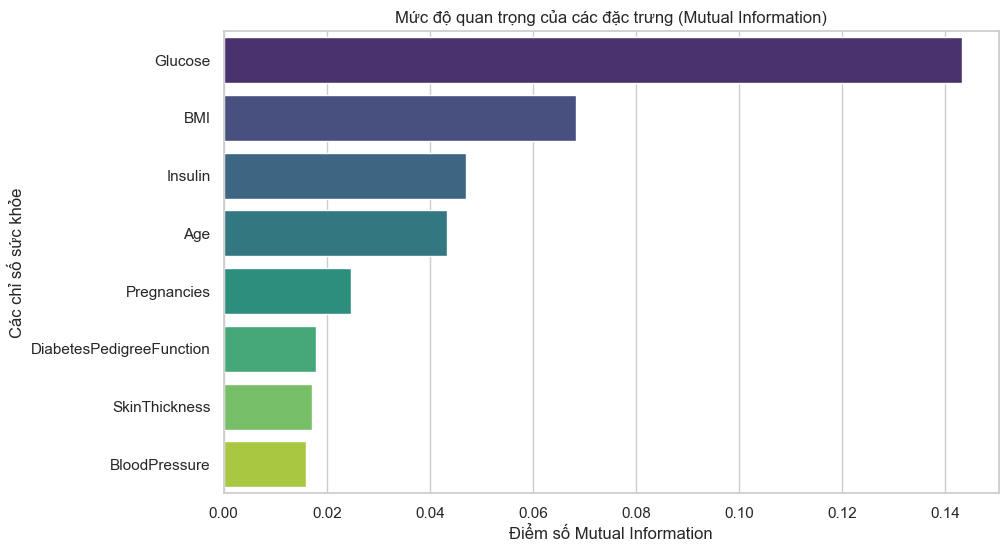

Bảng xếp hạng độ quan trọng:
                  Đặc trưng  Mutual Information
1                   Glucose            0.143154
5                       BMI            0.068362
4                   Insulin            0.046977
7                       Age            0.043283
0               Pregnancies            0.024760
6  DiabetesPedigreeFunction            0.017971
3             SkinThickness            0.017168
2             BloodPressure            0.015944


In [68]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=42)

# 2. Tạo DataFrame để hiển thị
mi_df = pd.DataFrame({
    'Đặc trưng': X.columns,
    'Mutual Information': mi_scores
}).sort_values(by='Mutual Information', ascending=False)

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x='Mutual Information', y='Đặc trưng', data=mi_df, palette='viridis')
plt.title('Mức độ quan trọng của các đặc trưng (Mutual Information)')
plt.xlabel('Điểm số Mutual Information')
plt.ylabel('Các chỉ số sức khỏe')
plt.show()

print("Bảng xếp hạng độ quan trọng:")
print(mi_df)

Bảng tầm quan trọng của đặc trưng (Random Forest):
                  Đặc trưng  Random Forest Importance
1                   Glucose                  0.255084
5                       BMI                  0.157326
6  DiabetesPedigreeFunction                  0.131354
7                       Age                  0.125167
4                   Insulin                  0.090175
0               Pregnancies                  0.088283
2             BloodPressure                  0.080757
3             SkinThickness                  0.071853


C:\Users\nguyenhoaibao\AppData\Local\Temp\ipykernel_23124\3344825116.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


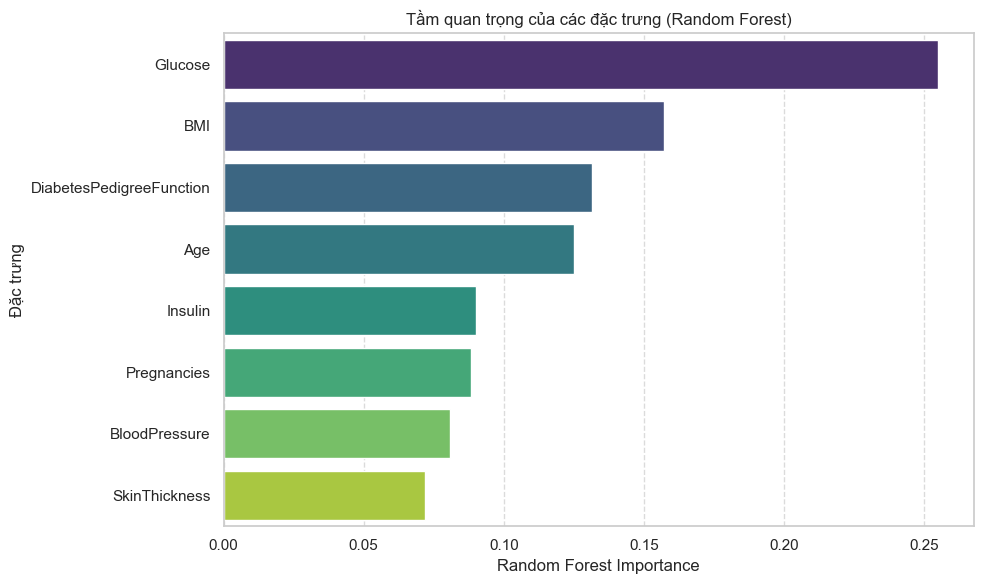

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. Giả sử bạn đã có X_train_imputed và y_train từ các bước trước

# 2. Khởi tạo và huấn luyện mô hình Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled ,y_train)

# 3. Lấy giá trị tầm quan trọng của các đặc trưng
importances = rf_model.feature_importances_
feature_names = X.columns # X là DataFrame gốc chứa tên các cột

# 4. Tạo DataFrame để quản lý và sắp xếp
feature_importance_df = pd.DataFrame({
    'Đặc trưng': feature_names,
    'Random Forest Importance': importances
}).sort_values(by='Random Forest Importance', ascending=False)

# 5. Hiển thị bảng dữ liệu (giống phần bên trái ảnh)
print("Bảng tầm quan trọng của đặc trưng (Random Forest):")
print(feature_importance_df.to_string(index=True))

# 6. Vẽ biểu đồ (giống phần bên phải ảnh)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Random Forest Importance', 
    y='Đặc trưng', 
    data=feature_importance_df, 
    palette='viridis' # Tạo dải màu từ tím đến vàng xanh như trong ảnh
)

plt.title('Tầm quan trọng của các đặc trưng (Random Forest)')
plt.xlabel('Random Forest Importance')
plt.ylabel('Đặc trưng')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

,Feature,VIF,Đánh giá
0,Age,1.597555,Tốt
1,BMI,1.596334,Tốt
2,SkinThickness,1.442165,Tốt
3,Pregnancies,1.436444,Tốt
4,Glucose,1.370033,Tốt
5,BloodPressure,1.284095,Tốt
6,Insulin,1.265369,Tốt
7,DiabetesPedigreeFunction,1.043647,Tốt


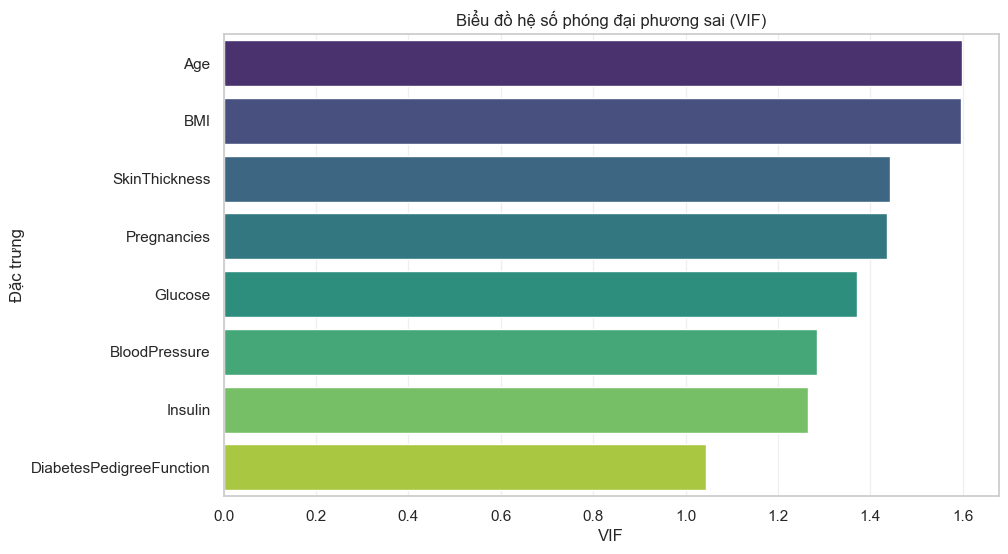

In [70]:


if not isinstance(X_train_scaled, pd.DataFrame):
    X_train_vif = pd.DataFrame(X_train_scaled, columns=X.columns)
else:
    X_train_vif = X_train_scaled.copy()


X_train_vif_with_const = sm.add_constant(X_train_vif)


vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_vif_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_vif_with_const.values, i) 
                   for i in range(X_train_vif_with_const.shape[1])]

vif_data = vif_data[vif_data["Feature"] != "const"]

vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

vif_data["Đánh giá"] = vif_data["VIF"].apply(lambda x: "Tốt" if x < 5 else "Chưa tốt")
display(vif_data)


plt.figure(figsize=(10, 6))
sns.barplot(x="VIF", y="Feature", data=vif_data, hue="Feature", palette="viridis", legend=False)
plt.title("Biểu đồ hệ số phóng đại phương sai (VIF)")
plt.xlabel("VIF")
plt.ylabel("Đặc trưng")
plt.grid(axis='x', linestyle='-', alpha=0.3)
plt.show()

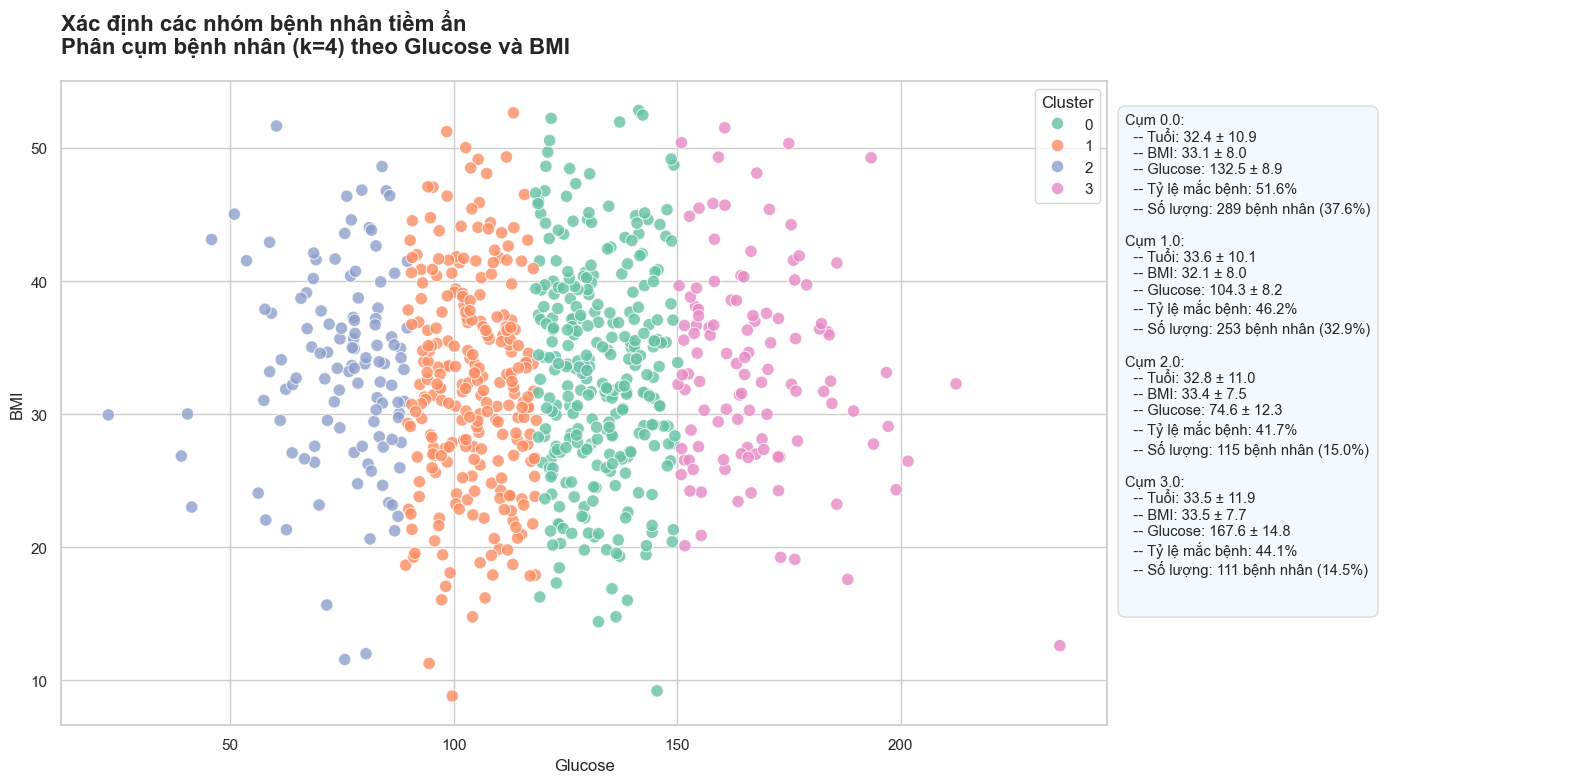

In [71]:

# 1. Cấu hình Font tiếng Việt
plt.rcParams['font.family'] = 'Arial' 
plt.rcParams['axes.unicode_minus'] = False 

# 2. Tạo dữ liệu giả lập - DÙNG BIẾN RIÊNG BIỆT (df_cluster)
np.random.seed(42)
n_samples = 768
data_sim = {
    'Glucose': np.random.normal(120, 30, n_samples),
    'BMI': np.random.normal(32, 8, n_samples),
    'Age': np.random.normal(33, 11, n_samples),
    'Outcome': np.random.randint(0, 2, n_samples)
}
# Đổi tên từ df thành df_cluster để bảo vệ dữ liệu gốc Pima
df_cluster = pd.DataFrame(data_sim)

# 3. Phân cụm K-Means trên df_cluster
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(df_cluster[['Glucose', 'BMI']])

# 4. Tính toán thông số cho từng cụm (Sử dụng df_cluster)
cluster_stats = ""
for i in range(4):
    c_df = df_cluster[df_cluster['Cluster'] == i]
    stats = (
        f"Cụm {i}.0:\n"
        f"  -- Tuổi: {c_df['Age'].mean():.1f} ± {c_df['Age'].std():.1f}\n"
        f"  -- BMI: {c_df['BMI'].mean():.1f} ± {c_df['BMI'].std():.1f}\n"
        f"  -- Glucose: {c_df['Glucose'].mean():.1f} ± {c_df['Glucose'].std():.1f}\n"
        f"  -- Tỷ lệ mắc bệnh: {(c_df['Outcome'].mean()*100):.1f}%\n"
        f"  -- Số lượng: {len(c_df)} bệnh nhân ({(len(c_df)/n_samples*100):.1f}%)\n\n"
    )
    cluster_stats += stats

# 5. Vẽ biểu đồ
sns.set_theme(style="whitegrid", font="Arial")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [2.8, 1.2]})

# Vẽ Scatter plot với data=df_cluster
scatter = sns.scatterplot(
    data=df_cluster, x='Glucose', y='BMI', hue='Cluster', 
    palette='Set2', s=80, ax=ax1, alpha=0.8
)

ax1.set_title("Xác định các nhóm bệnh nhân tiềm ẩn\nPhân cụm bệnh nhân (k=4) theo Glucose và BMI", 
              fontsize=16, fontweight='bold', loc='left', pad=20)
ax1.set_xlabel("Glucose", fontsize=12)
ax1.set_ylabel("BMI", fontsize=12)

# 6. Thêm khung thông tin
ax2.axis('off')
ax2.text(0, 0.95, cluster_stats, transform=ax2.transAxes, 
         fontsize=10.5, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='aliceblue', edgecolor='lightgrey', alpha=0.8))

plt.tight_layout()
plt.show()

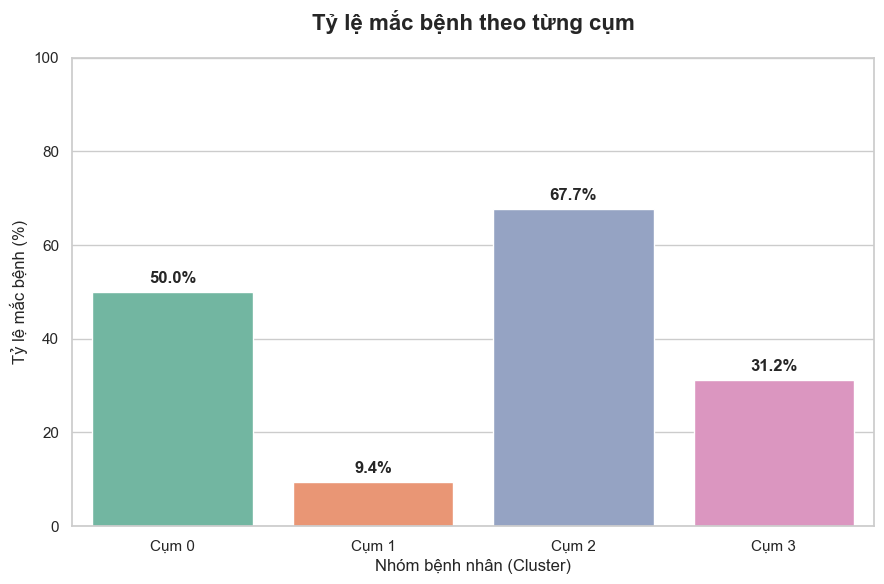

In [72]:
# Dữ liệu từ kết quả phân cụm (Cluster) của bạn
clusters = ['Cụm 0', 'Cụm 1', 'Cụm 2', 'Cụm 3']
rates = [50.0, 9.4, 67.7, 31.2]
colors_cluster = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'] 

plt.figure(figsize=(9, 6))
ax = sns.barplot(x=clusters, y=rates, palette=colors_cluster, hue=clusters, legend=False)

# Trang trí
plt.title("Tỷ lệ mắc bệnh theo từng cụm", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Tỷ lệ mắc bệnh (%)", fontsize=12)
plt.xlabel("Nhóm bệnh nhân (Cluster)", fontsize=12)
plt.ylim(0, 100)

# Thêm nhãn % trên đầu cột
for i, v in enumerate(rates):
    ax.text(i, v + 2, f"{v}%", ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

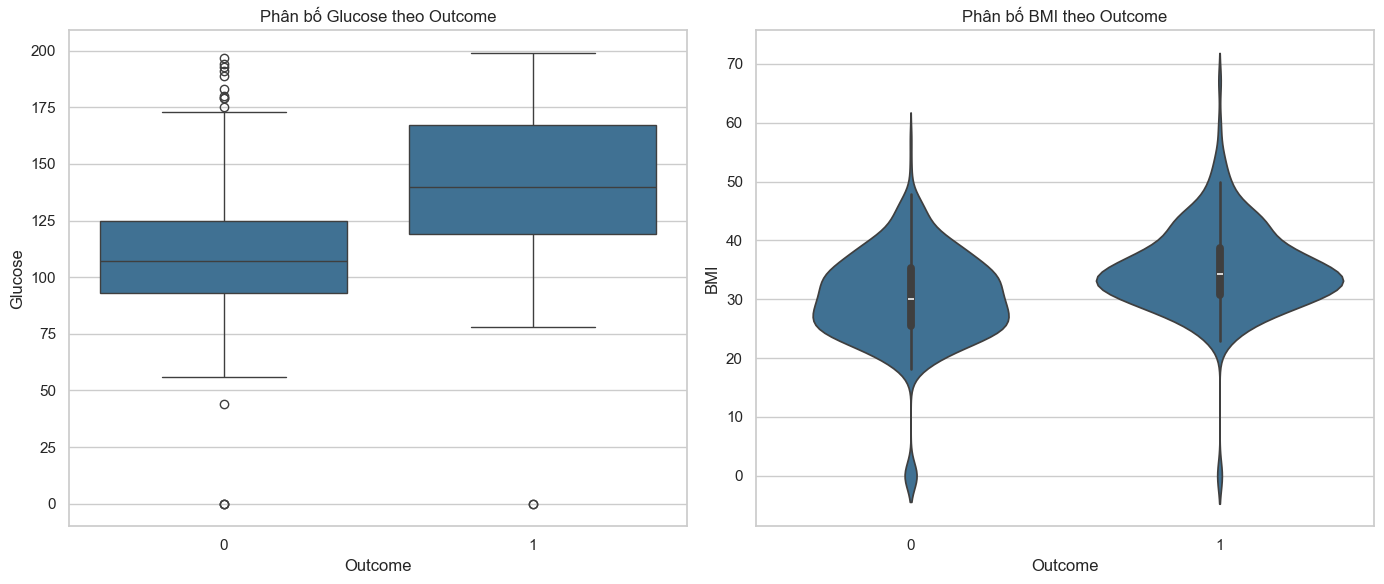

In [73]:
# Tạo một khung hình gồm 1 hàng và 2 cột
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Vẽ Boxplot cho Glucose ở cột đầu tiên
sns.boxplot(x='Outcome', y='Glucose', data=df, ax=axes[0], color='#3274a1')
axes[0].set_title('Phân bố Glucose theo Outcome')

# Vẽ Violinplot cho BMI ở cột thứ hai
sns.violinplot(x='Outcome', y='BMI', data=df, ax=axes[1], color='#3274a1')
axes[1].set_title('Phân bố BMI theo Outcome')

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

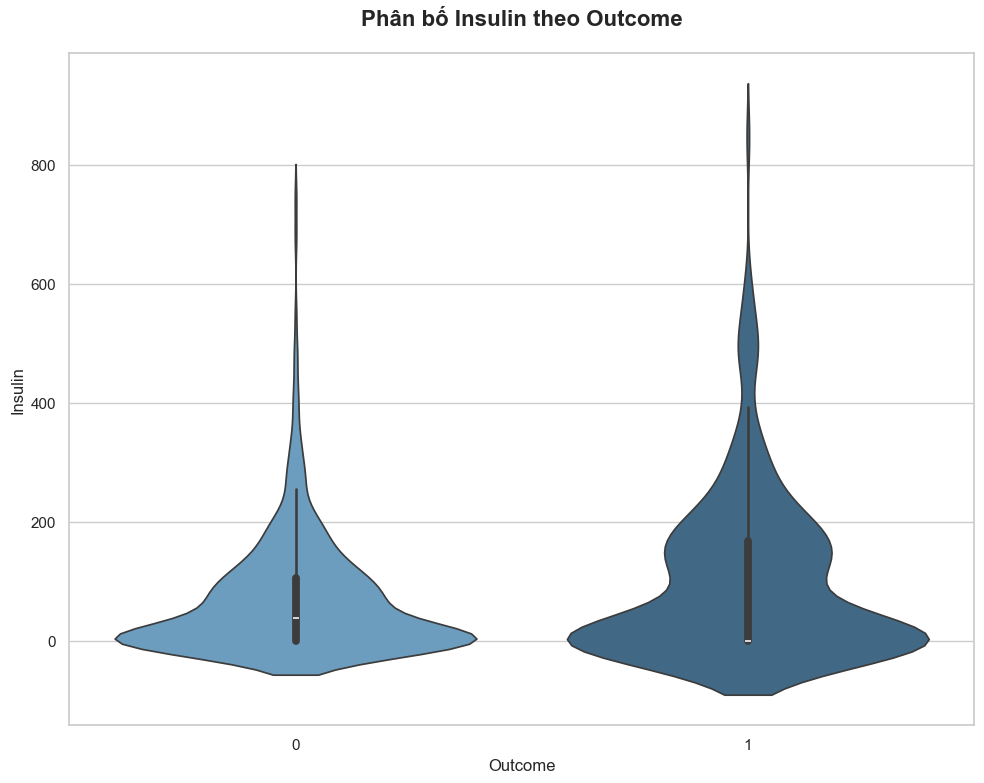

In [74]:
# 1. Thiết lập kích thước và phong cách
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# 2. Vẽ biểu đồ Violin chuẩn (Thêm hue='Outcome' và legend=False để hết cảnh báo)
sns.violinplot(
    data=df, 
    x='Outcome', 
    y='Insulin', 
    hue='Outcome',      # Gán màu theo biến Outcome
    palette='Blues_d', 
    inner='box', 
    legend=False        # Ẩn chú thích vì trục X đã ghi rõ 0 và 1
)

# 3. Thêm tiêu đề và nhãn
plt.title('Phân bố Insulin theo Outcome', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Insulin', fontsize=12)

# 4. Hiển thị
plt.tight_layout()
plt.show()

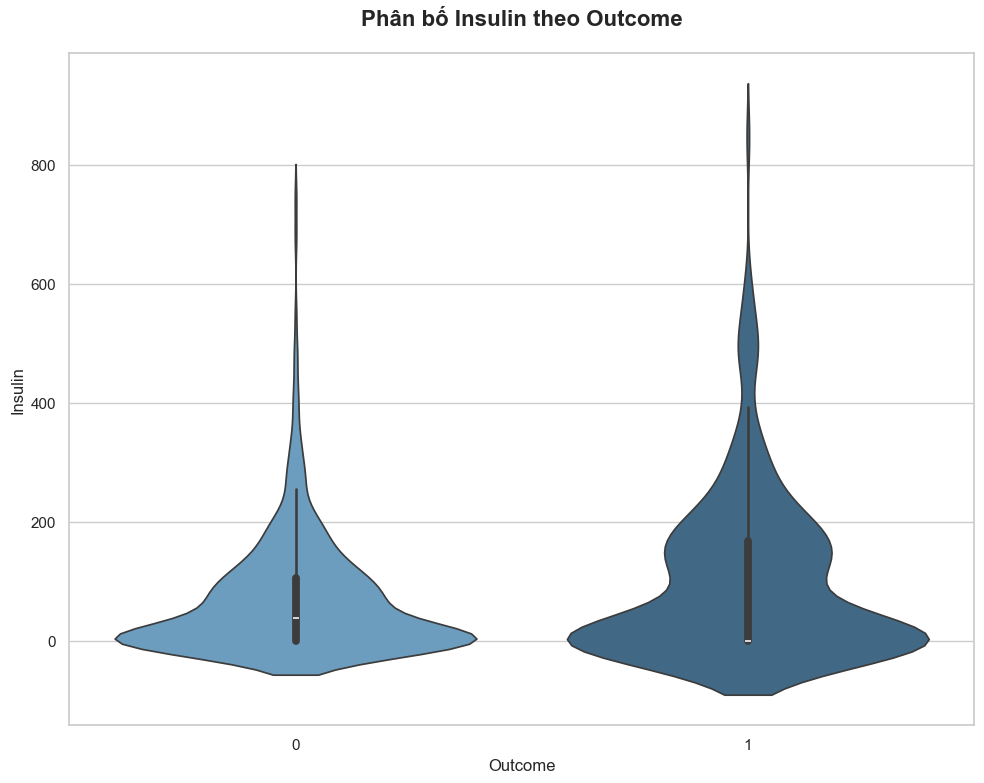

In [75]:
# 1. Thiết lập phong cách đồ họa chuyên nghiệp
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

# 2. Vẽ biểu đồ Violin cho chỉ số Insulin theo Outcome
sns.violinplot(
    data=df, 
    x='Outcome', 
    y='Insulin', 
    hue='Outcome', 
    palette='Blues_d', 
    inner='box', 
    legend=False
)

# 3. Cấu hình tiêu đề và nhãn giống hệt trong ảnh mẫu của bạn
plt.title('Phân bố Insulin theo Outcome', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Insulin', fontsize=12)

# 4. Tinh chỉnh hiển thị để rõ nét hơn
plt.tight_layout()
plt.show()

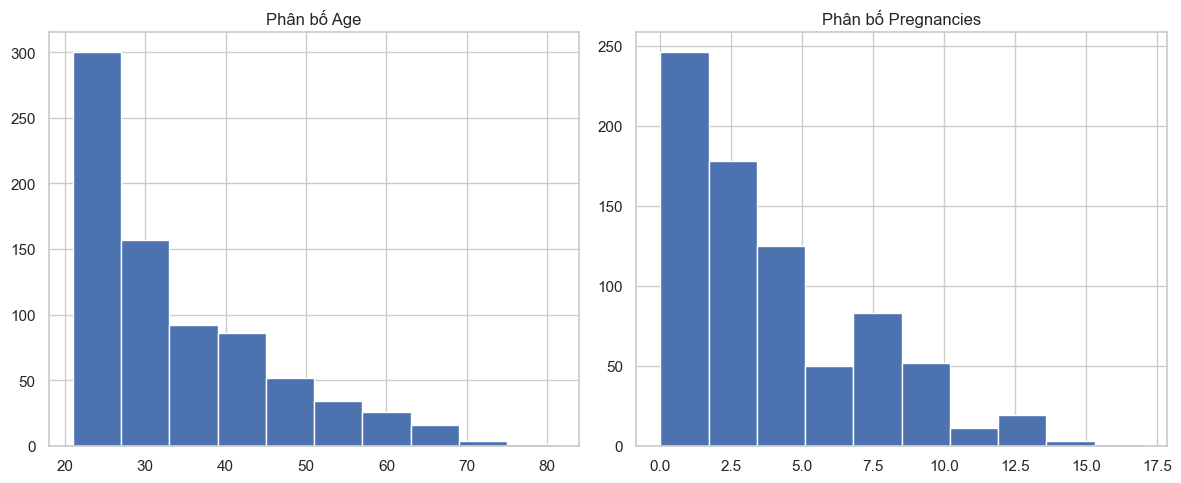

In [76]:
# Khởi tạo khung hình với 2 biểu đồ nằm cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Vẽ Histogram cho cột Age
df['Age'].hist(ax=axes[0])
axes[0].set_title('Phân bố Age')

# Vẽ Histogram cho cột Pregnancies
df['Pregnancies'].hist(ax=axes[1])
axes[1].set_title('Phân bố Pregnancies')

# Điều chỉnh khoảng cách và hiển thị
plt.tight_layout()
plt.show()

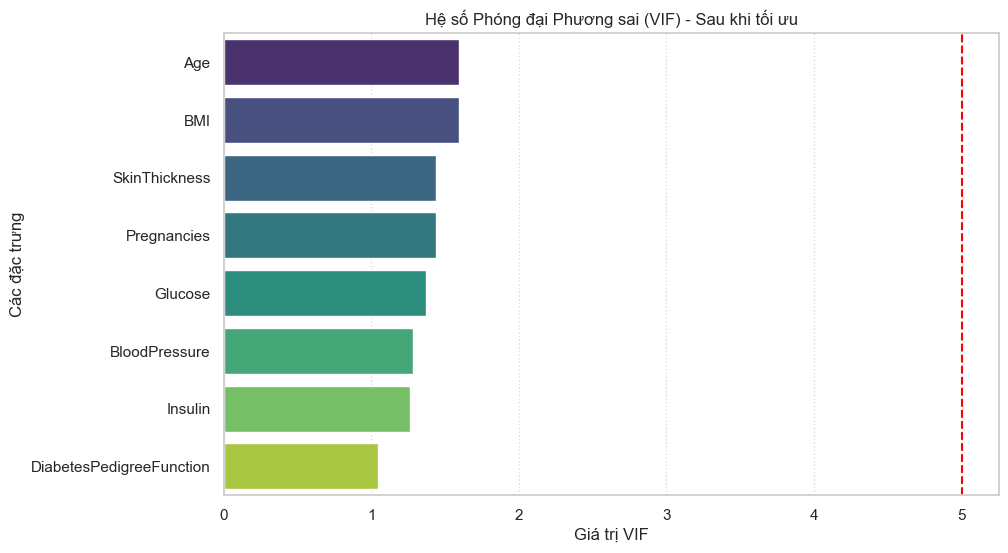

,Feature,VIF
7,Age,1.597555
5,BMI,1.596334
3,SkinThickness,1.442165
0,Pregnancies,1.436444
1,Glucose,1.370033
2,BloodPressure,1.284095
4,Insulin,1.265369
6,DiabetesPedigreeFunction,1.043647


In [77]:


# 1. Chuẩn bị dữ liệu (Thêm hằng số để VIF không bị ảo)
X_train_vif_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_with_const = sm.add_constant(X_train_vif_df)

# 2. Tính toán VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_vif_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i+1) for i in range(len(X_train_vif_df.columns))]

# 3. Sắp xếp để vẽ biểu đồ cho đẹp
vif_data = vif_data.sort_values(by="VIF", ascending=False)

# 4. Vẽ biểu đồ (Đã sửa lỗi palette và hue)
plt.figure(figsize=(10, 6))
sns.barplot(
    x="VIF", 
    y="Feature", 
    data=vif_data, 
    hue="Feature",      # Thêm cái này để hết cảnh báo đỏ
    palette="viridis", 
    legend=False        # Tắt chú thích dư thừa
)

# Thêm đường giới hạn VIF = 5 (ngưỡng an toàn)
plt.axvline(x=5, color='red', linestyle='--', label='Ngưỡng an toàn (VIF=5)')
plt.title("Hệ số Phóng đại Phương sai (VIF) - Sau khi tối ưu")
plt.xlabel("Giá trị VIF")
plt.ylabel("Các đặc trưng")
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.show()

# Hiển thị bảng kết quả
display(vif_data)

Độ chính xác của Logistic Regression: 0.7639


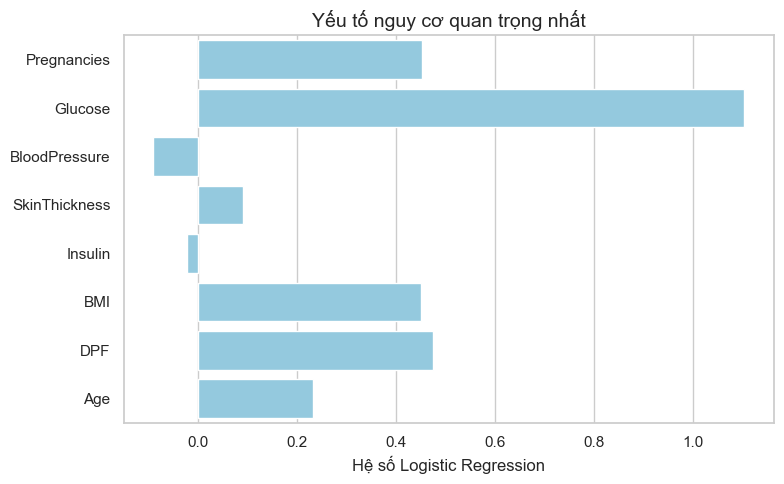

In [78]:


# 1. Khởi tạo và huấn luyện mô hình Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Đánh giá nhanh độ chính xác (tuỳ chọn)
y_pred_log = log_reg.predict(X_test_scaled)
print(f"Độ chính xác của Logistic Regression: {log_reg.score(X_test_scaled, y_test):.4f}")

# 2. Lấy hệ số (coefficients) của mô hình
coefs = log_reg.coef_[0]

# Khai báo tên các đặc trưng (Features) theo đúng thứ tự cột trong tập dữ liệu
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DPF', 'Age']

# Tạo một DataFrame chứa thông tin để vẽ biểu đồ
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefs})

# 3. Vẽ biểu đồ mức độ quan trọng (giống hình minh hoạ)
plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', color='skyblue')

# Cài đặt tiêu đề và nhãn
plt.title('Yếu tố nguy cơ quan trọng nhất', fontsize=14)
plt.xlabel('Hệ số Logistic Regression', fontsize=12)
plt.ylabel('') 

# Căn chỉnh và hiển thị đồ thị
plt.tight_layout()
plt.show()

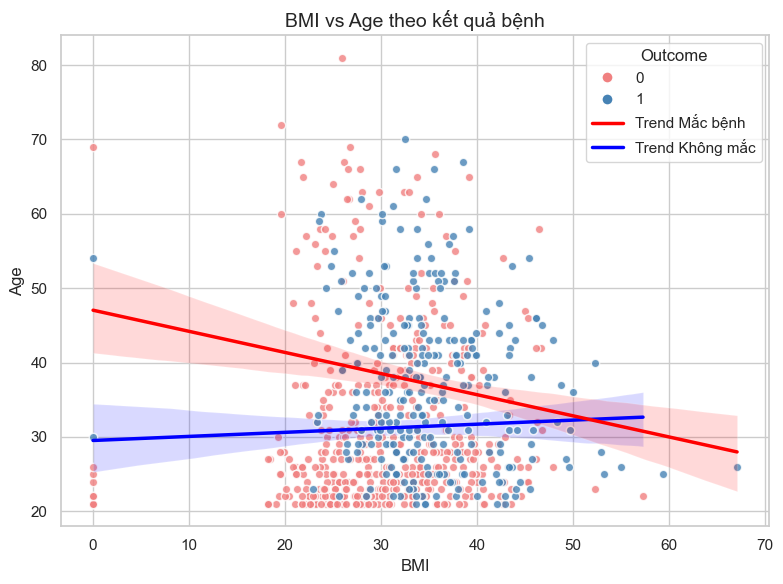

In [79]:


# Thiết lập kích thước khung hình
plt.figure(figsize=(8, 6))

# 1. Vẽ phân bố cho nhóm Outcome = 0 (Không mắc bệnh)
sns.regplot(
    data=df[df['Outcome'] == 0], 
    x='BMI', y='Age', 
    scatter_kws={'color': 'lightcoral', 'alpha': 0.8, 'edgecolor': 'w'}, 
    line_kws={'color': 'blue', 'linewidth': 2.5}
)

# 2. Vẽ phân bố cho nhóm Outcome = 1 (Mắc bệnh)
sns.regplot(
    data=df[df['Outcome'] == 1], 
    x='BMI', y='Age', 
    scatter_kws={'color': 'steelblue', 'alpha': 0.8, 'edgecolor': 'w'}, 
    line_kws={'color': 'red', 'linewidth': 2.5}
)

# Tùy chỉnh tiêu đề và nhãn
plt.title('BMI vs Age theo kết quả bệnh', fontsize=14)
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Age', fontsize=12)

# 3. Tạo Custom Legend (Ghi chú tùy chỉnh) sao cho giống ảnh nhất
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='0', markerfacecolor='lightcoral', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='1', markerfacecolor='steelblue', markersize=8),
    Line2D([0], [0], color='red', lw=2.5, label='Trend Mắc bệnh'),
    Line2D([0], [0], color='blue', lw=2.5, label='Trend Không mắc')
]

plt.legend(handles=legend_elements, title='Outcome', loc='upper right')

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

--- KẾT QUẢ CỦA LOGISTIC REGRESSION (BASELINE) ---
Accuracy (Độ chính xác): 0.7569444444444444

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83        97
           1       0.65      0.55      0.60        47

    accuracy                           0.76       144
   macro avg       0.72      0.70      0.71       144
weighted avg       0.75      0.76      0.75       144



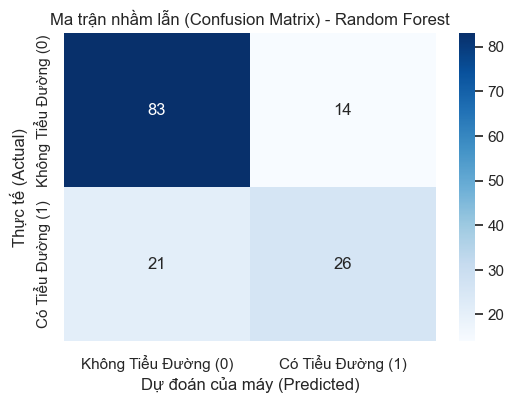

In [80]:
# Import các thư viện phân lớp và đánh giá
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Chia dữ liệu thành tập Huấn luyện (80%) và tập Kiểm tra (20%)
# Lưu ý: Nếu ở trên bạn đã chạy lệnh này rồi thì có thể bỏ qua
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("--- KẾT QUẢ CỦA LOGISTIC REGRESSION (BASELINE) ---")

# 1. Khởi tạo mô hình
log_reg = LogisticRegression(max_iter=1000)

# 2. Huấn luyện mô hình (Training)
log_reg.fit(X_train, y_train)

# 3. Phân lớp/Dự đoán trên tập Test
y_pred_log = log_reg.predict(X_test)

# 4. Đánh giá
print("Accuracy (Độ chính xác):", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

# Tính toán ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred_log)

# Vẽ biểu đồ Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Không Tiểu Đường (0)', 'Có Tiểu Đường (1)'],
            yticklabels=['Không Tiểu Đường (0)', 'Có Tiểu Đường (1)'])
plt.title('Ma trận nhầm lẫn (Confusion Matrix) - Random Forest')
plt.xlabel('Dự đoán của máy (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.show()

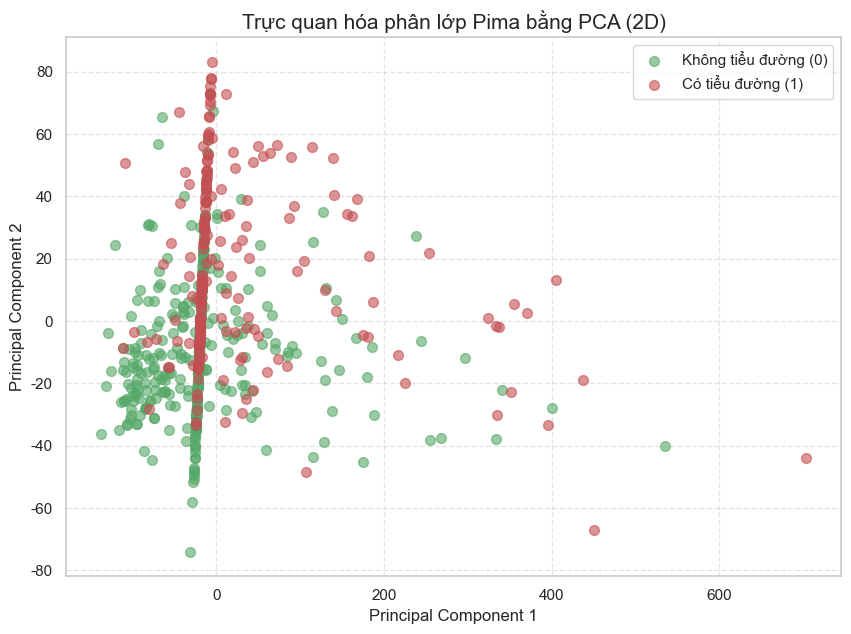

In [81]:
from sklearn.decomposition import PCA
import pandas as pd

# 1. Khởi tạo PCA để giảm xuống còn 2 chiều (PC1 và PC2)
pca = PCA(n_components=2)

# 2. Áp dụng PCA lên tập dữ liệu huấn luyện X_train
# Lưu ý: X_train nên là dữ liệu đã qua StandardScaler ở các bước trước
principalComponents = pca.fit_transform(X_train)

# 3. Tạo DataFrame mới để chứa kết quả PCA
principalDf = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])

# 4. Gộp nhãn y_train vào để tô màu cho các điểm
finalDf = pd.concat([principalDf, y_train.reset_index(drop=True)], axis=1)

# 5. Vẽ biểu đồ
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.set_title('Trực quan hóa phân lớp Pima bằng PCA (2D)', fontsize=15)

# Cấu hình cho 2 lớp: 0 (Không bệnh) và 1 (Có bệnh)
targets = [0, 1]
targets_desc = {0: 'Không tiểu đường (0)', 1: 'Có tiểu đường (1)'}
colors = ['g', 'r'] # Xanh cho an toàn, Đỏ cho có bệnh

for target, color in zip(targets, colors):
    indicesToKeep = finalDf['Outcome'] == target # Lưu ý: Tên cột nhãn của bạn là 'Outcome'
    ax.scatter(finalDf.loc[indicesToKeep, 'PC1'],
               finalDf.loc[indicesToKeep, 'PC2'],
               c=color,
               s=50,
               alpha=0.6, # Độ trong suốt để dễ nhìn các điểm chồng lấn
               label=targets_desc[target])

ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()